In [1]:
import pandas as pd
import seaborn as sns
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
import matplotlib.patches as mpatches
from utils import *
import matplotlib.colors as mcolors

In [3]:
DATA_DIR_DBSCAN="data/clustering_features_10_algorithms_dbscan"
DATA_DIR_KMEANS="data/clustering_features_x_only_10_algorithms_kmeans_2pow_no_init"

In [4]:
def visualize_dbscan_kmeans(dimensions, problems, algorithms, runs, plot_y=False, data_dir1=None, data_dir2=None, save=False, eps=0.1, ms=100):
    if data_dir1 is None or data_dir2 is None:
        raise Exception("directories for both clustering algorithms must be given to run the comparison")
    
    for dimension in dimensions:
        directory1 = f'{data_dir1}/cluster_distributions/dim_{dimension}/eps{eps}_ms{ms}'
        directory2 = f'{data_dir2}/cluster_distributions/dim_{dimension}'
        
        for problem in problems:
            cluster_centers1 = pd.read_csv(f'{data_dir1}/cluster_centers/dim_{dimension}/eps{eps}_ms{ms}/{problem}.csv', index_col=0)
            cluster_centers2 = pd.read_csv(f'{data_dir2}/cluster_centers/dim_{dimension}/{problem}.csv', index_col=0)
            cluster_centers1 = {index: ', '.join([str(round(row[c], 2)) for c in row.keys()]) for index, row in cluster_centers1.iterrows()}
            cluster_centers2 = {index: ', '.join([str(round(row[c], 2)) for c in row.keys()]) for index, row in cluster_centers2.iterrows()}

            solutions1 = pd.read_parquet(f'{data_dir1}/clustering_results/dim_{dimension}/eps{eps}_ms{ms}/{problem}.parquet')
            solutions2 = pd.read_parquet(f'{data_dir2}/clustering_results/dim_{dimension}/{problem}.parquet')
            
            file_loc1 = f'{directory1}/{problem}.csv'
            file_loc2 = f'{directory2}/{problem}.csv'
            
            if not os.path.isfile(file_loc1) or not os.path.isfile(file_loc2):
                print(f"Skipping {problem} — missing distribution file")
                continue
                
            df1 = pd.read_csv(file_loc1, index_col=[0, 1, 2])
            df1.columns = [f'{int(c)} (Center: {cluster_centers1[int(c)]})' for c in df1.columns]
            df2 = pd.read_csv(file_loc2, index_col=[0, 1, 2])
            df2.columns = [f'{int(c)} (Center: {cluster_centers2[int(c)]})' for c in df2.columns]
            
            for a in algorithms:
                for run in runs:
                    print(problem, a, run)
                    
                    # --- figure with 2 heatmaps side by side ---
                    fig, axes = plt.subplots(1, 2, figsize=(20, int(df1.loc[a, run].shape[0] / 3) + 4))
                    
                    # KMeans heatmap
                    sns.heatmap(
                        df1.loc[a, run].replace(0, np.nan),
                        annot=True, fmt='.0f',
                        ax=axes[0],
                        cmap='YlGnBu'
                    )
                    axes[0].set_title(f'KMeans — {a} run {run}')
                    axes[0].set_xlabel('Cluster')
                    axes[0].set_ylabel('Iteration')
                    
                    # DBSCAN heatmap
                    sns.heatmap(
                        df2.loc[a, run].replace(0, np.nan),
                        annot=True, fmt='.0f',
                        ax=axes[1],
                        cmap='YlGnBu'
                    )
                    axes[1].set_title(f'DBSCAN — {a} run {run}, eps {eps}, ms {ms}')
                    axes[1].set_xlabel('Cluster')
                    axes[1].set_ylabel('Iteration')
                    
                    plt.suptitle(f'Problem: {problem}', fontsize=14)
                    plt.tight_layout()
                    
                    if save:
                        file_name = f'{problem}_{a}_run_{run}_comparison.pdf'
                        plt.savefig(f'figures_clustering_new/{file_name}', bbox_inches='tight')
                    
                    plt.show()

F16_I3 AugmentedAEO 1


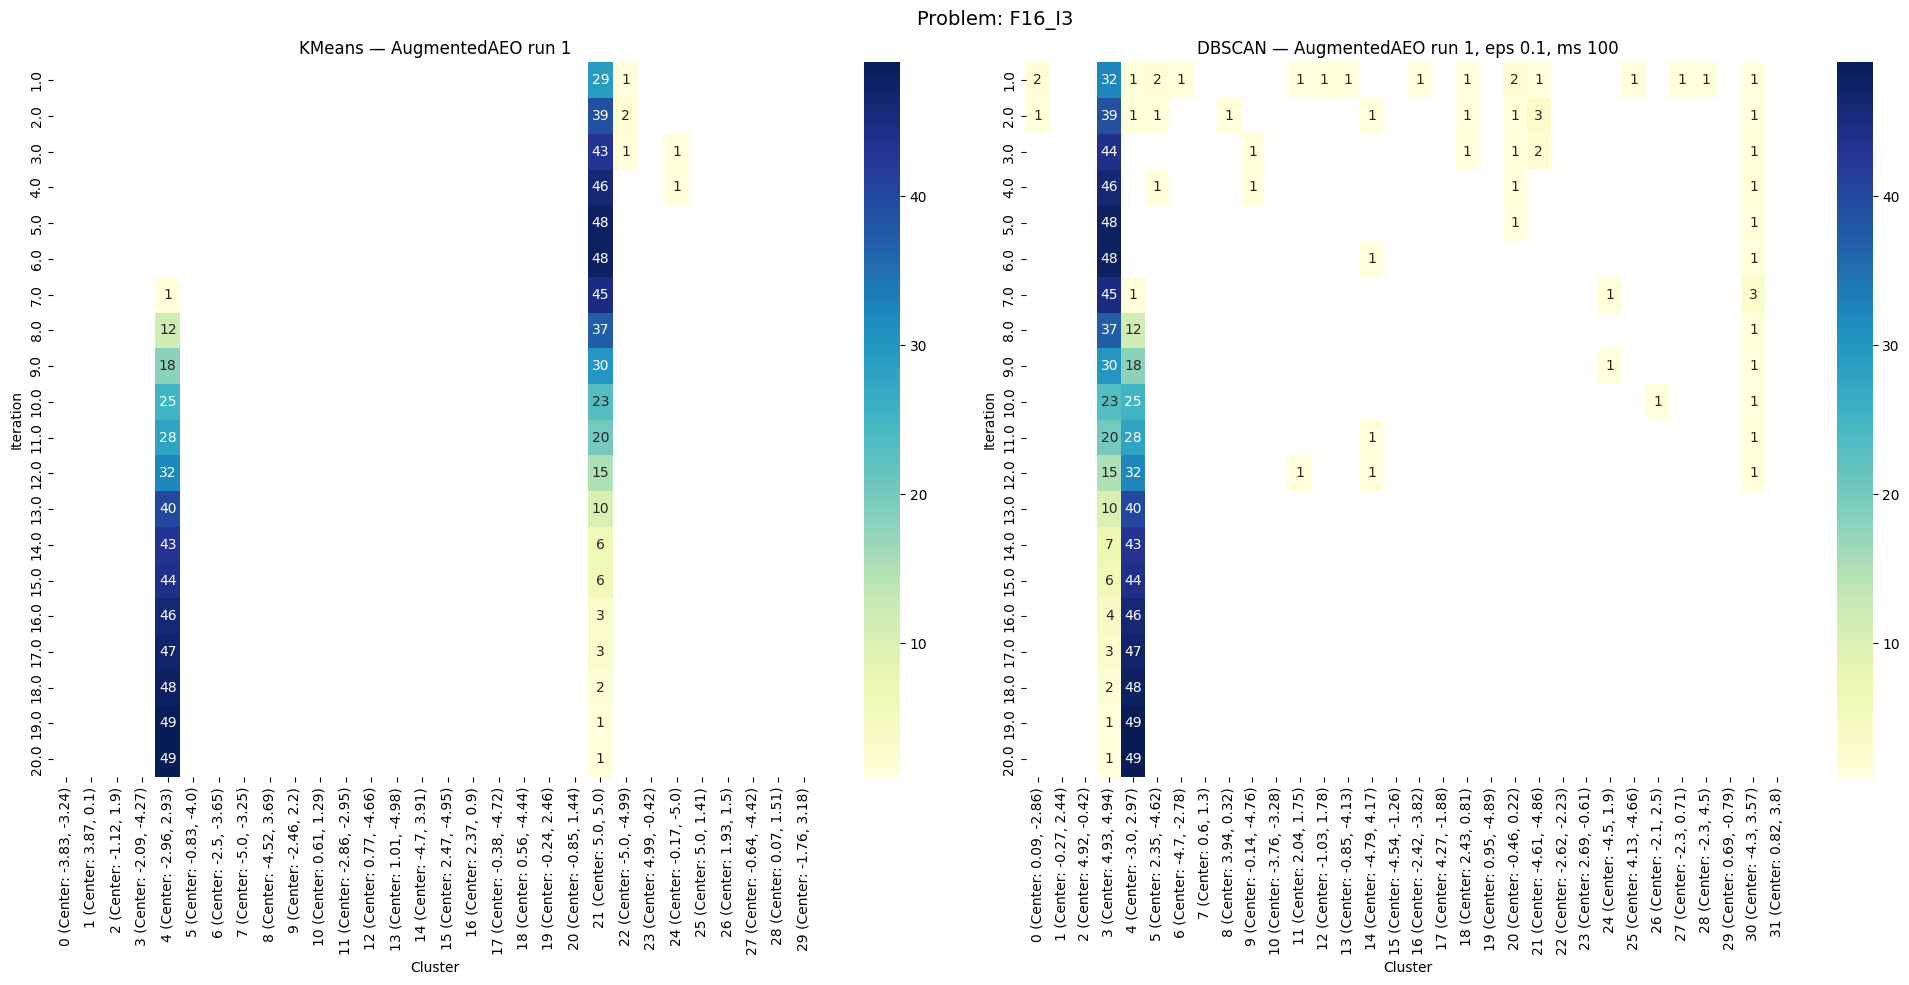

F16_I3 AugmentedAEO 2


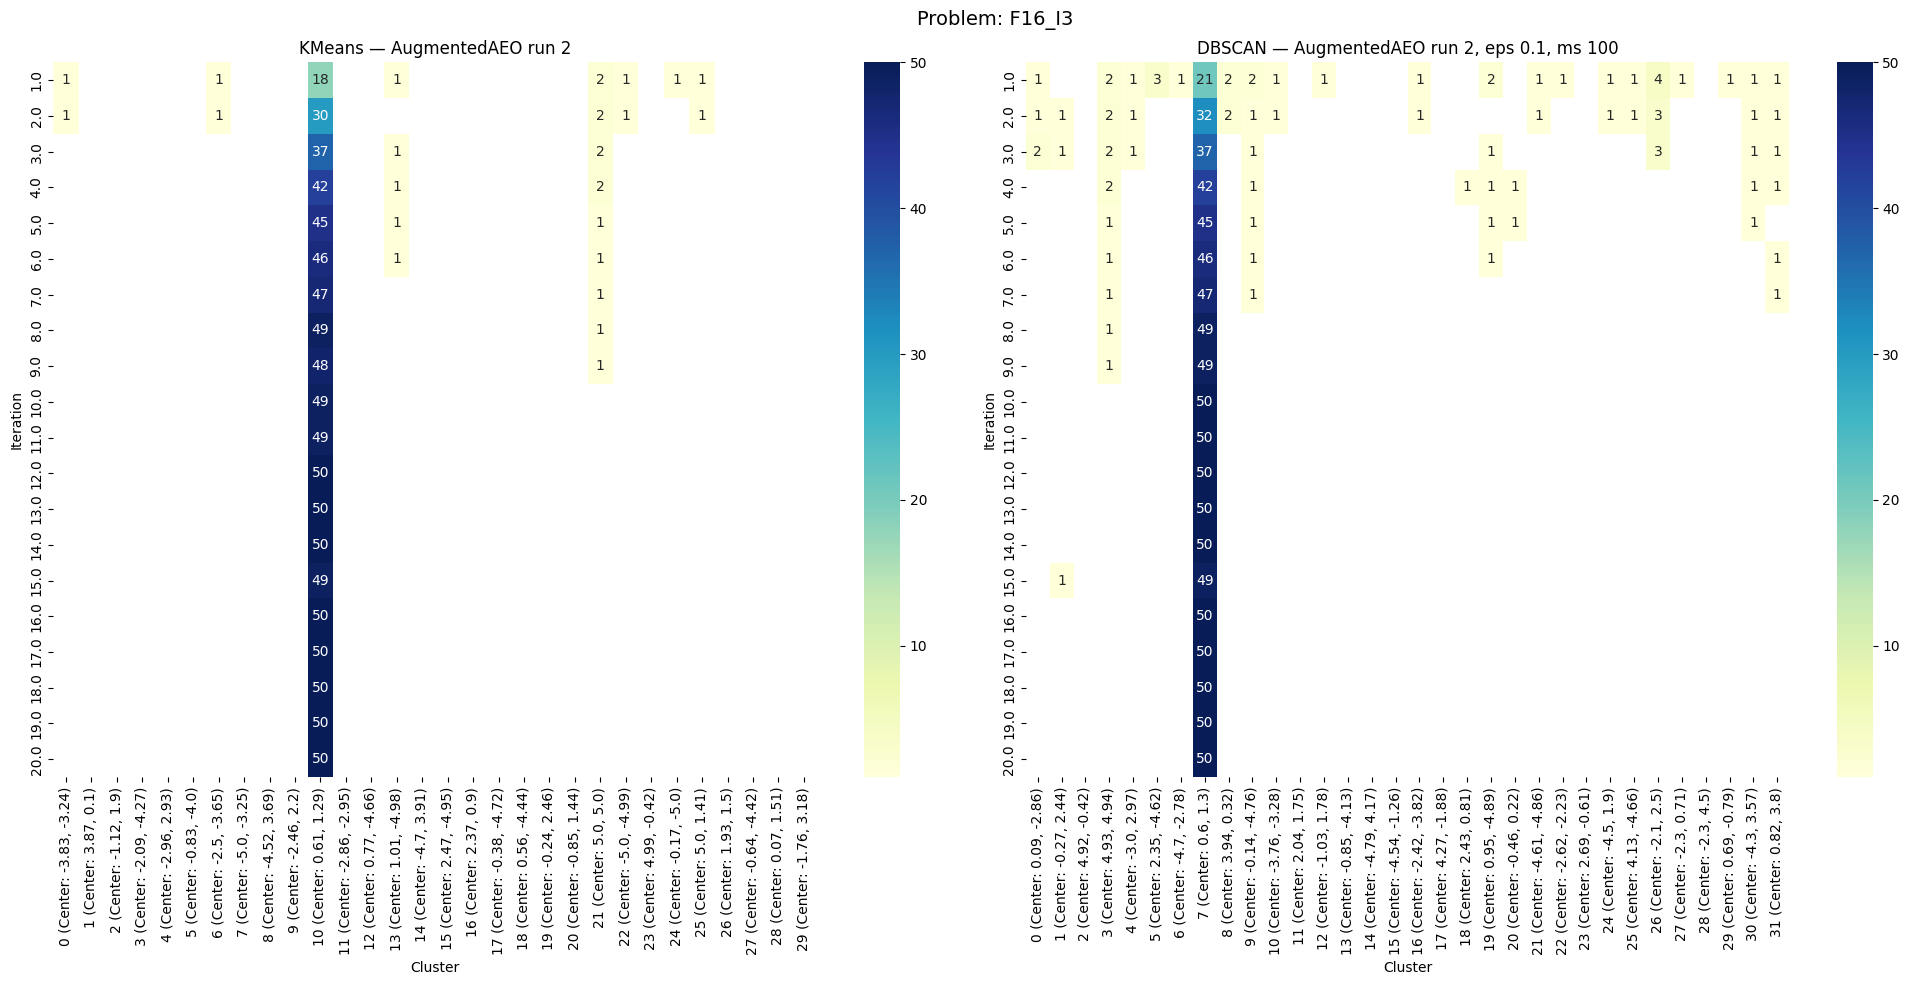

F16_I3 AugmentedAEO 3


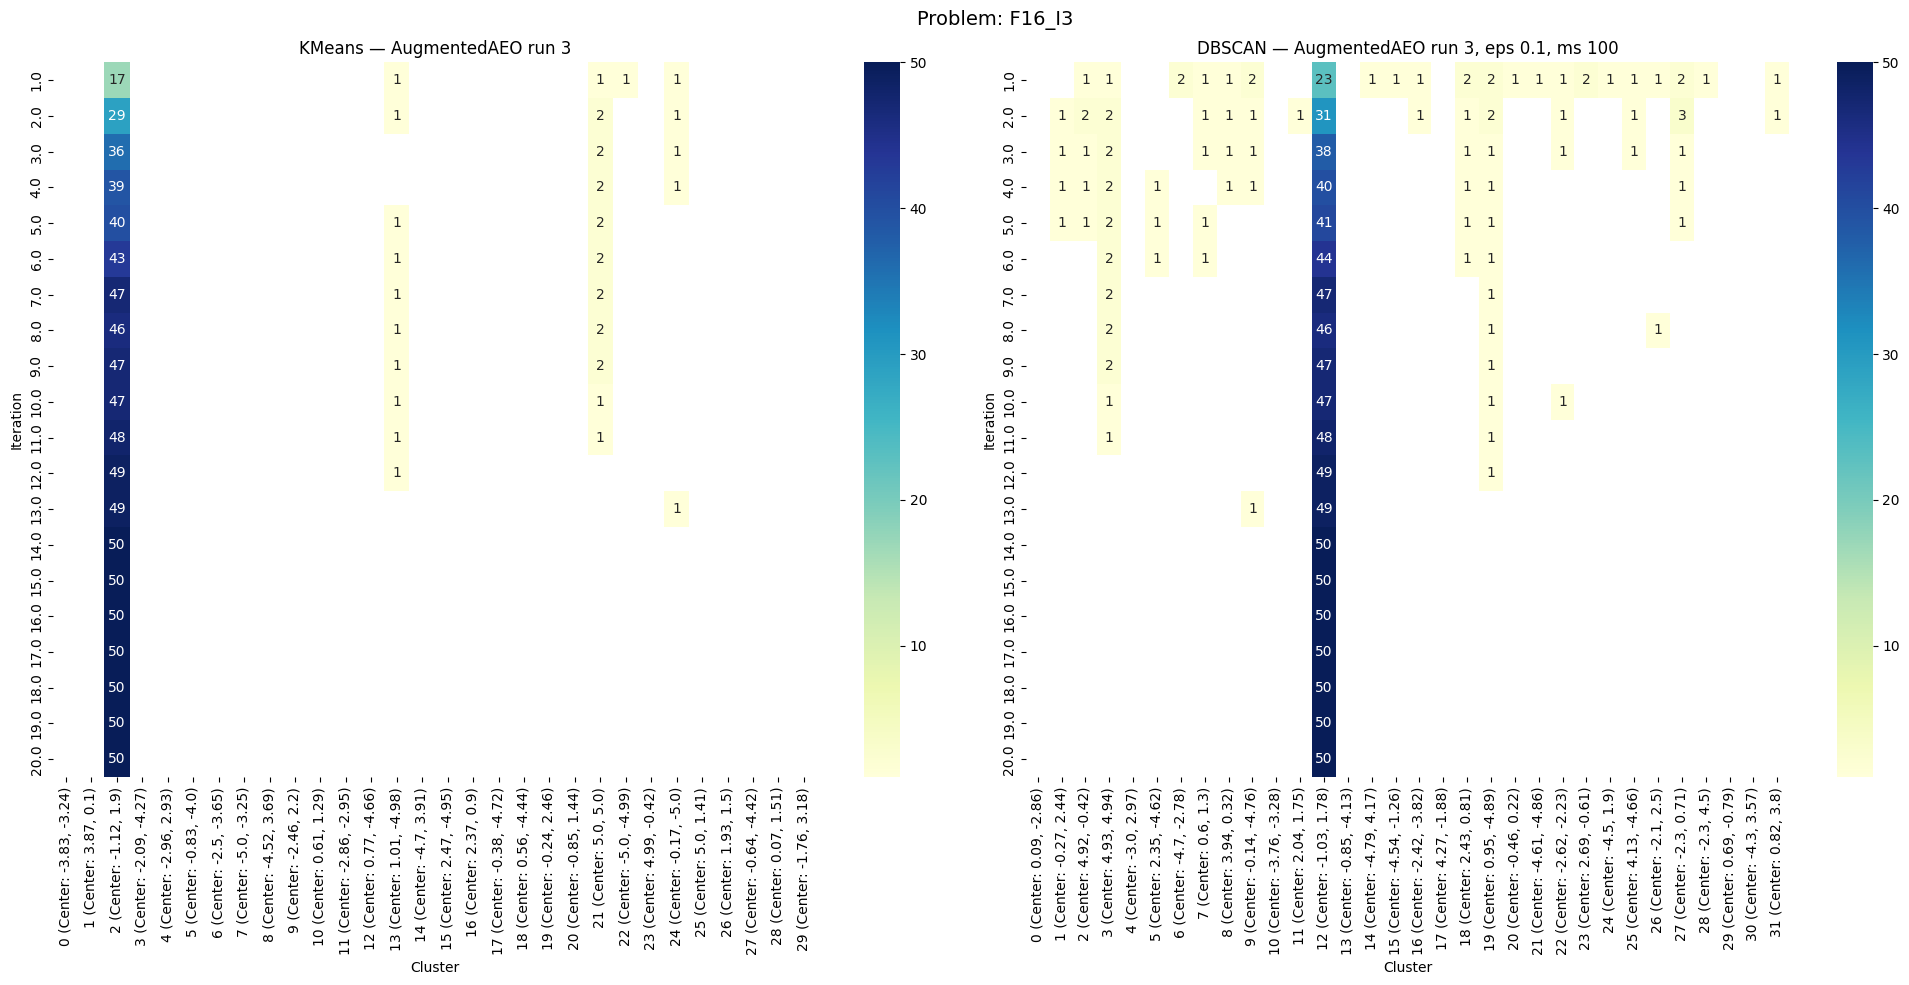

F16_I3 AugmentedAEO 4


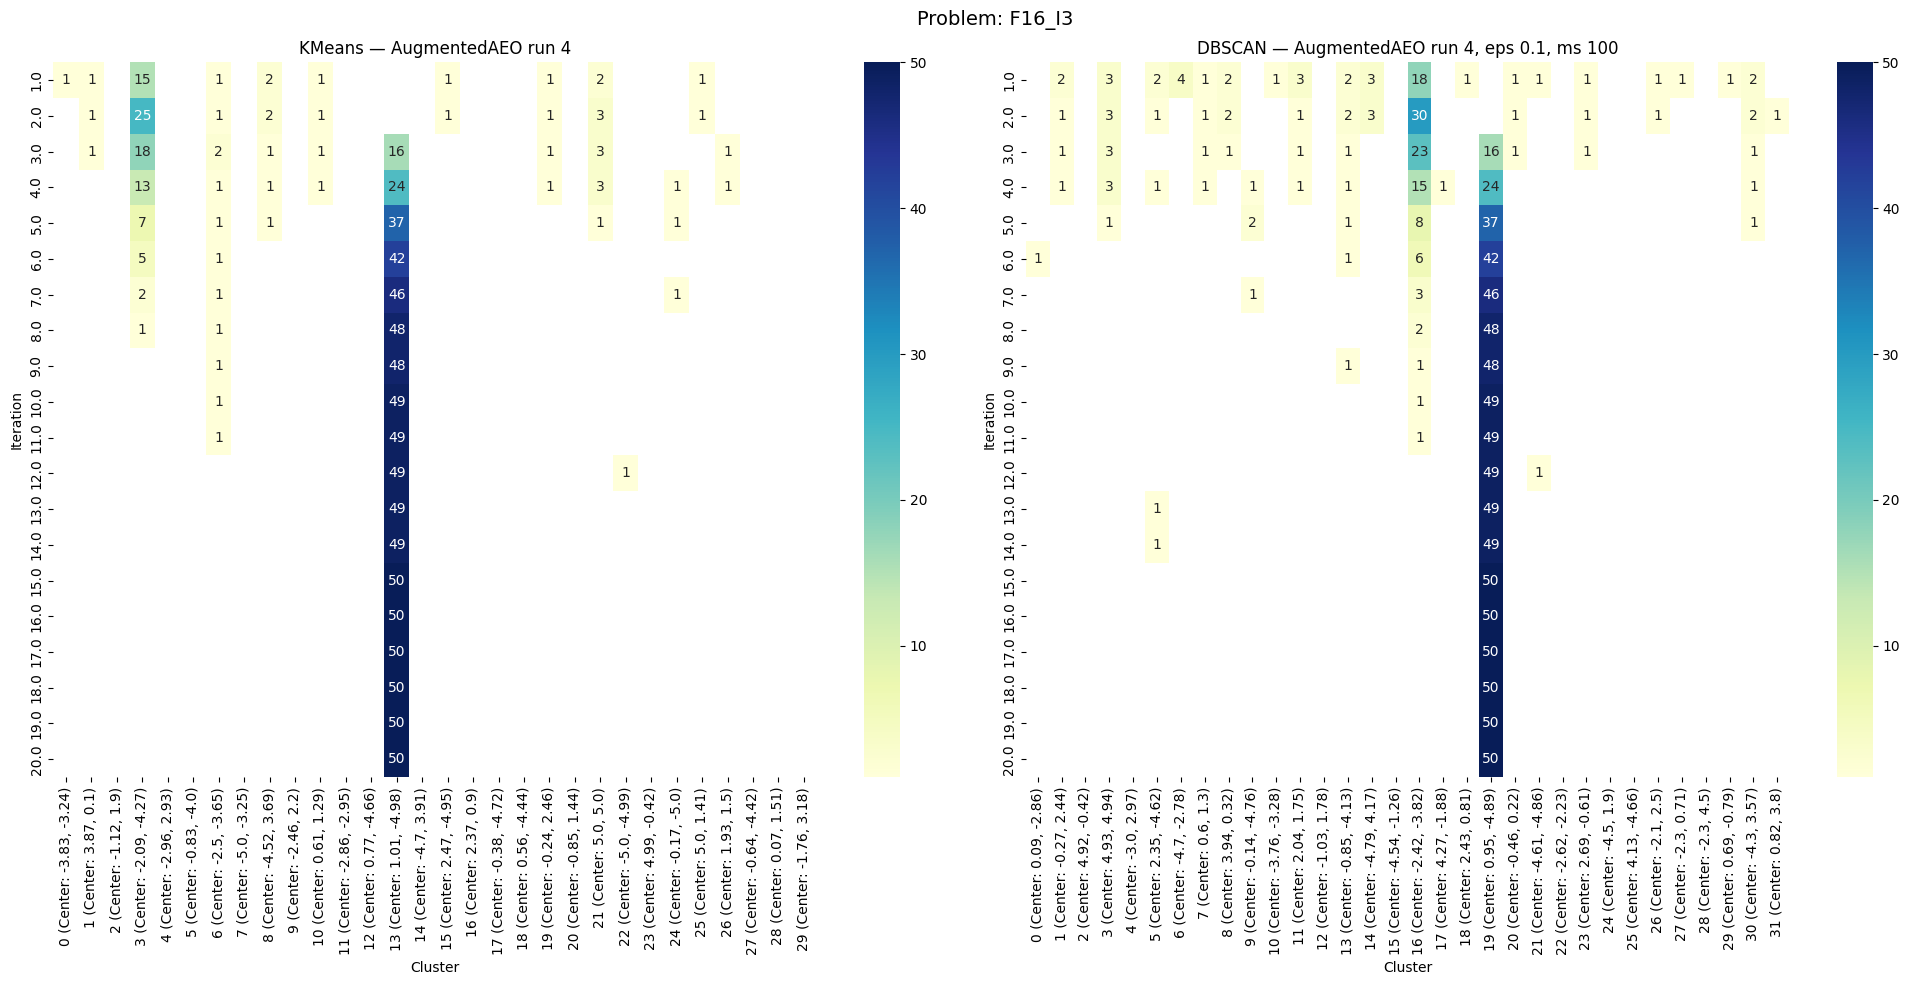

F16_I3 AugmentedAEO 5


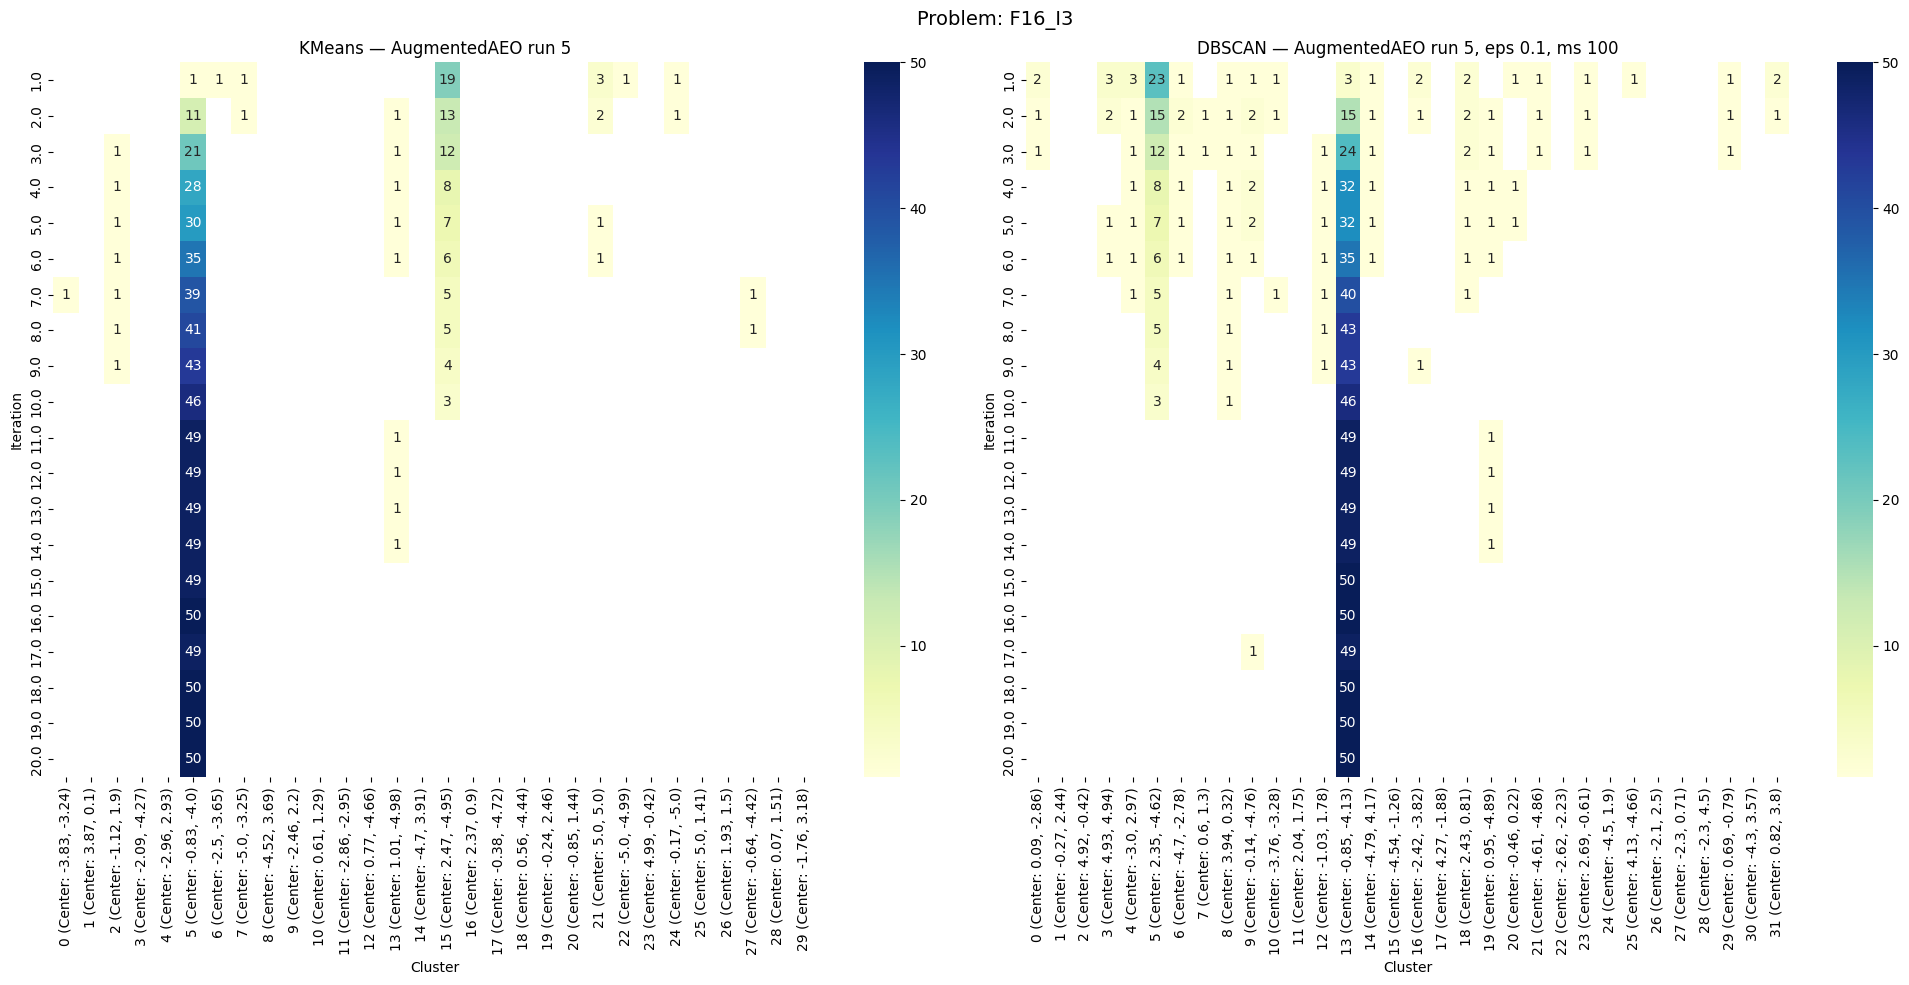

F16_I3 OriginalAEO 1


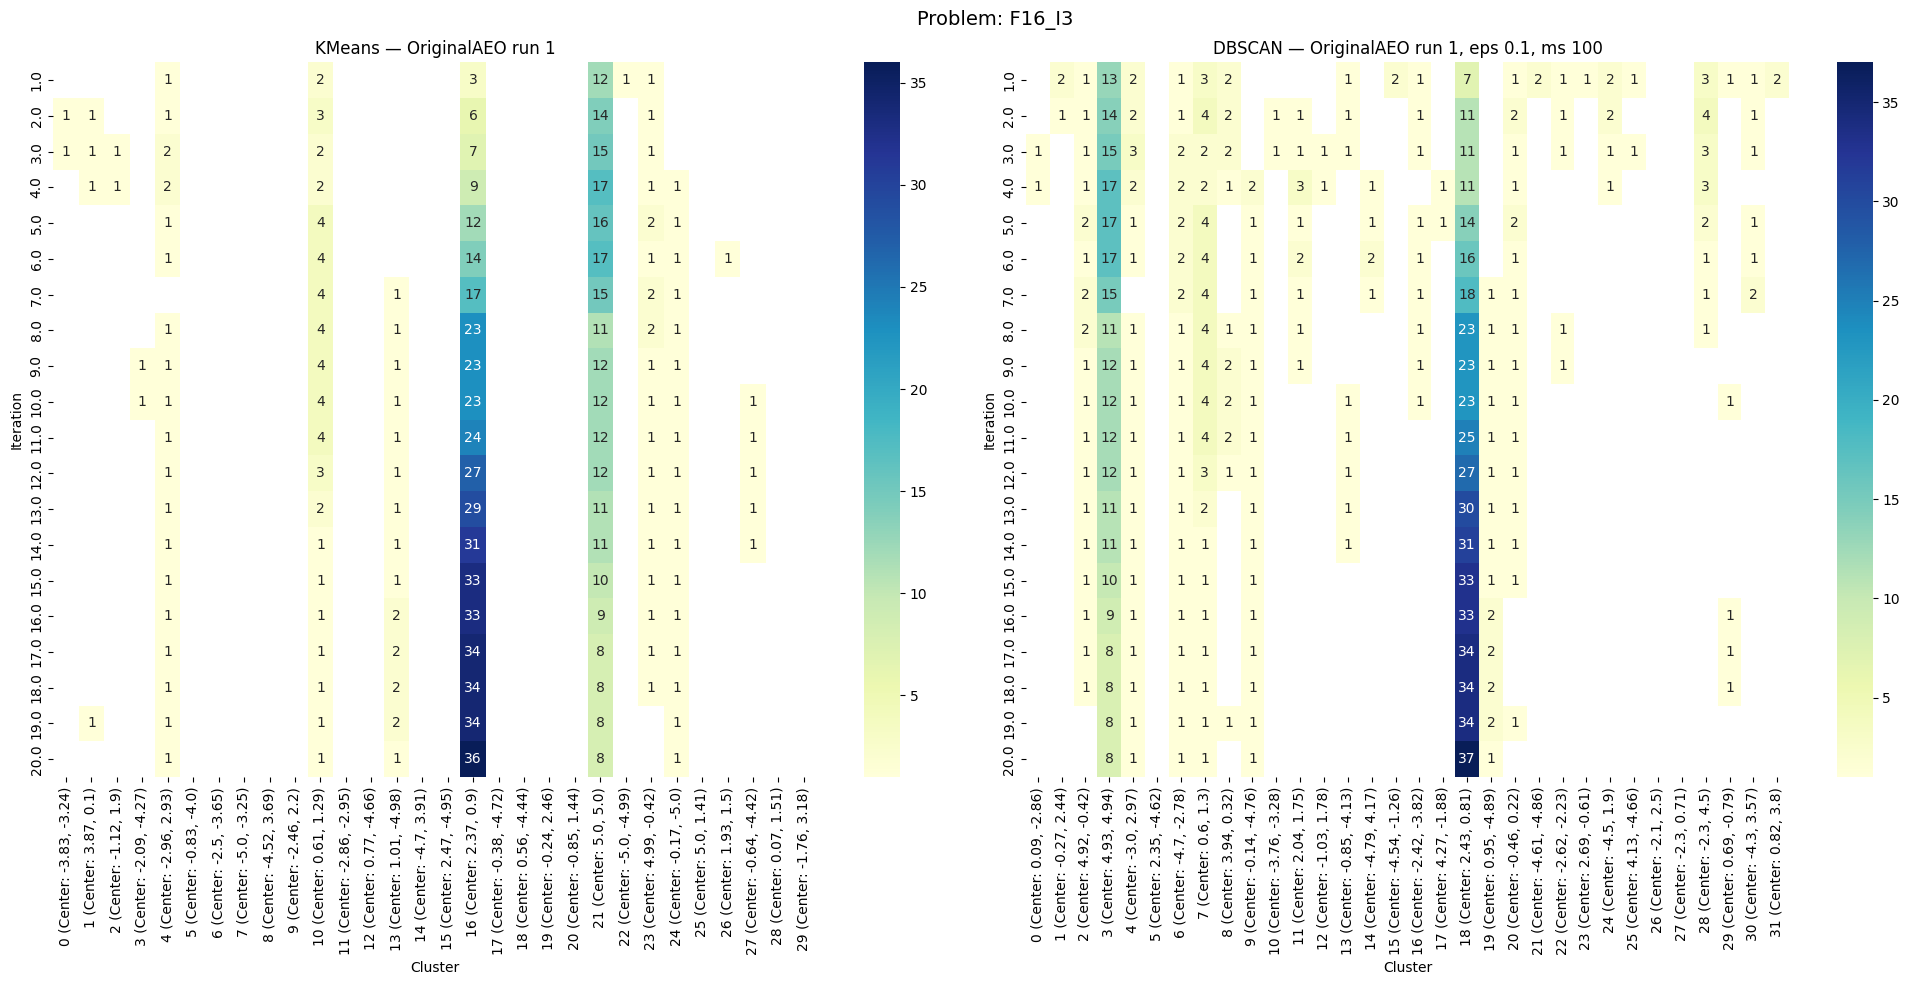

F16_I3 OriginalAEO 2


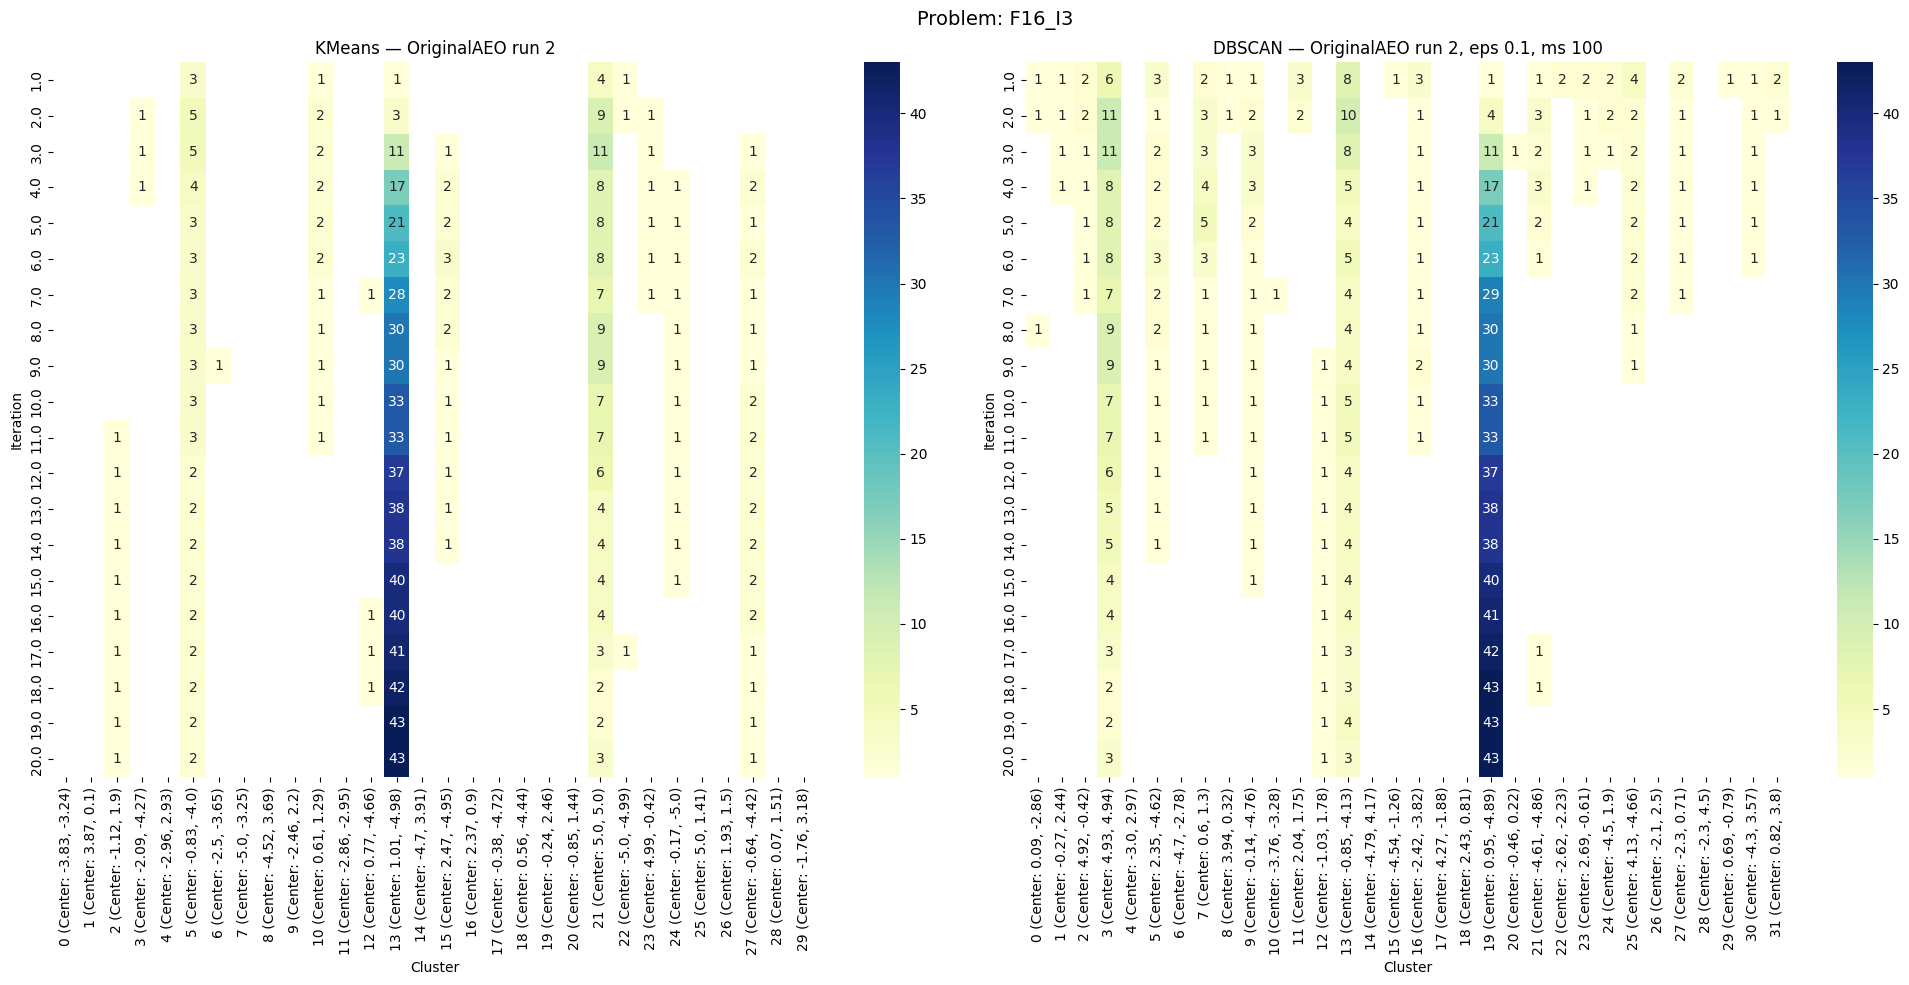

F16_I3 OriginalAEO 3


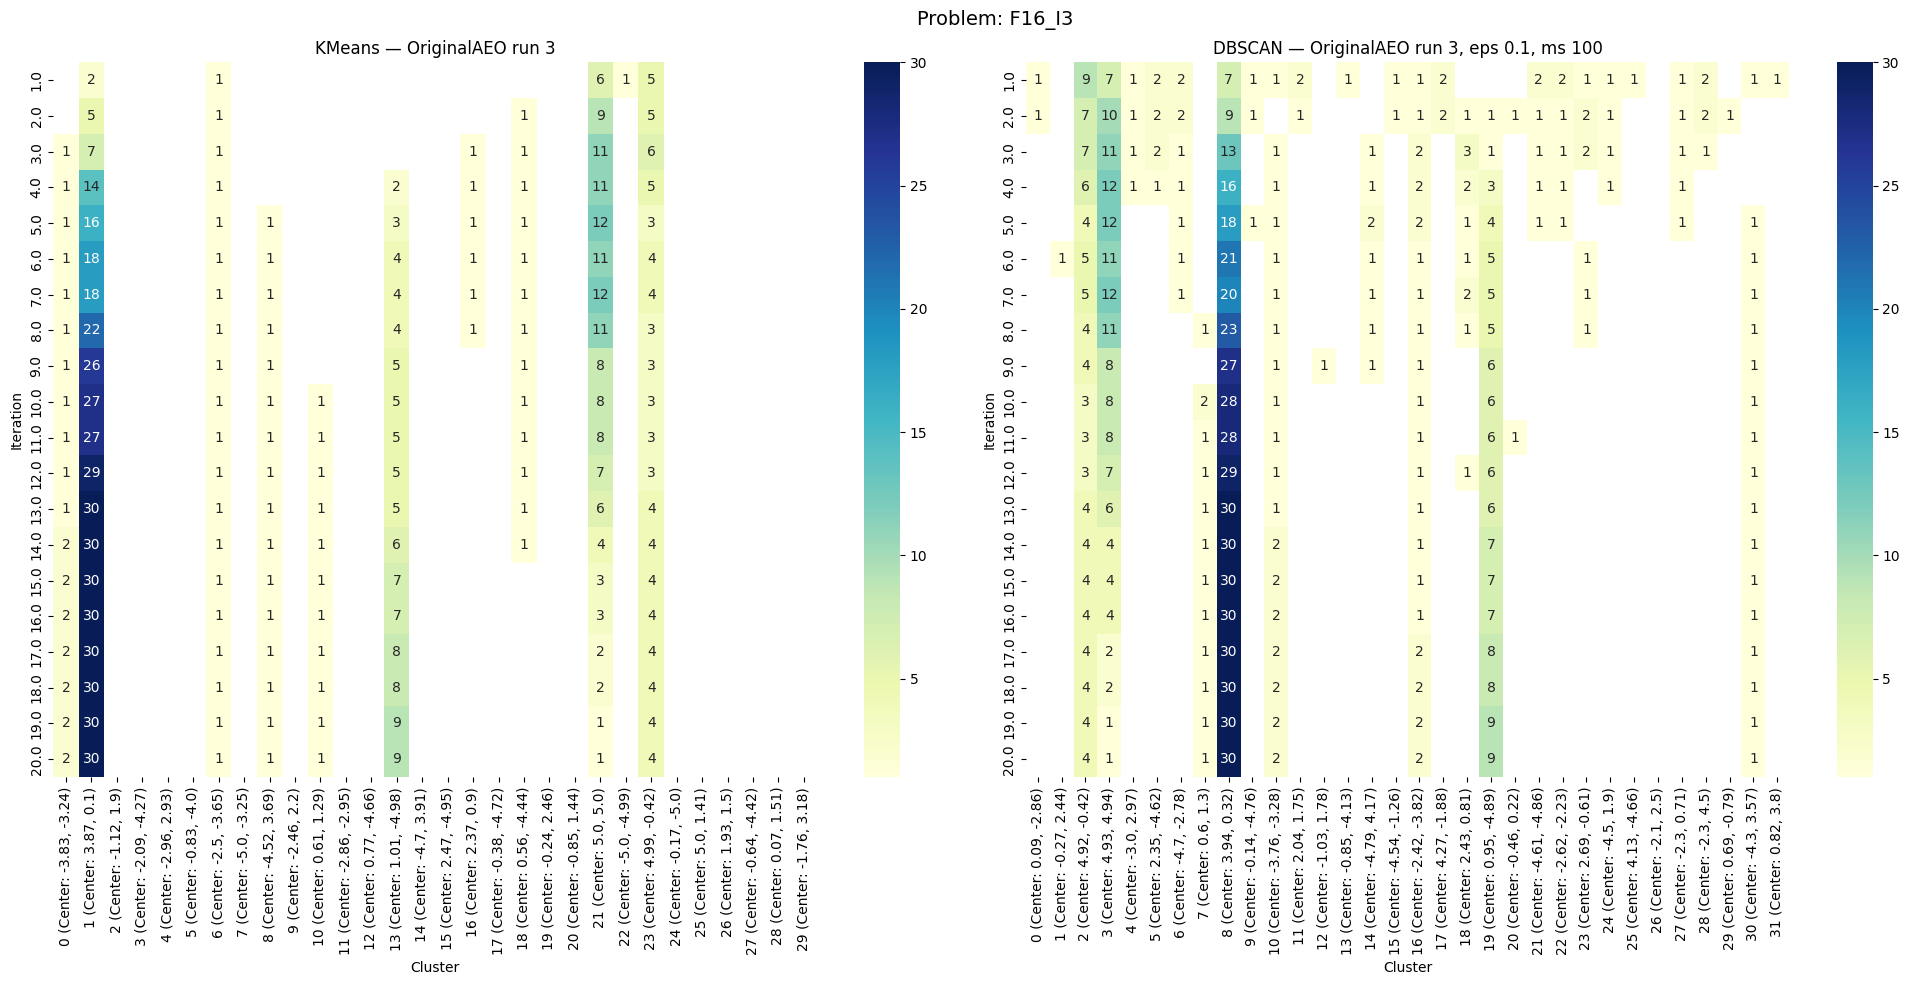

F16_I3 OriginalAEO 4


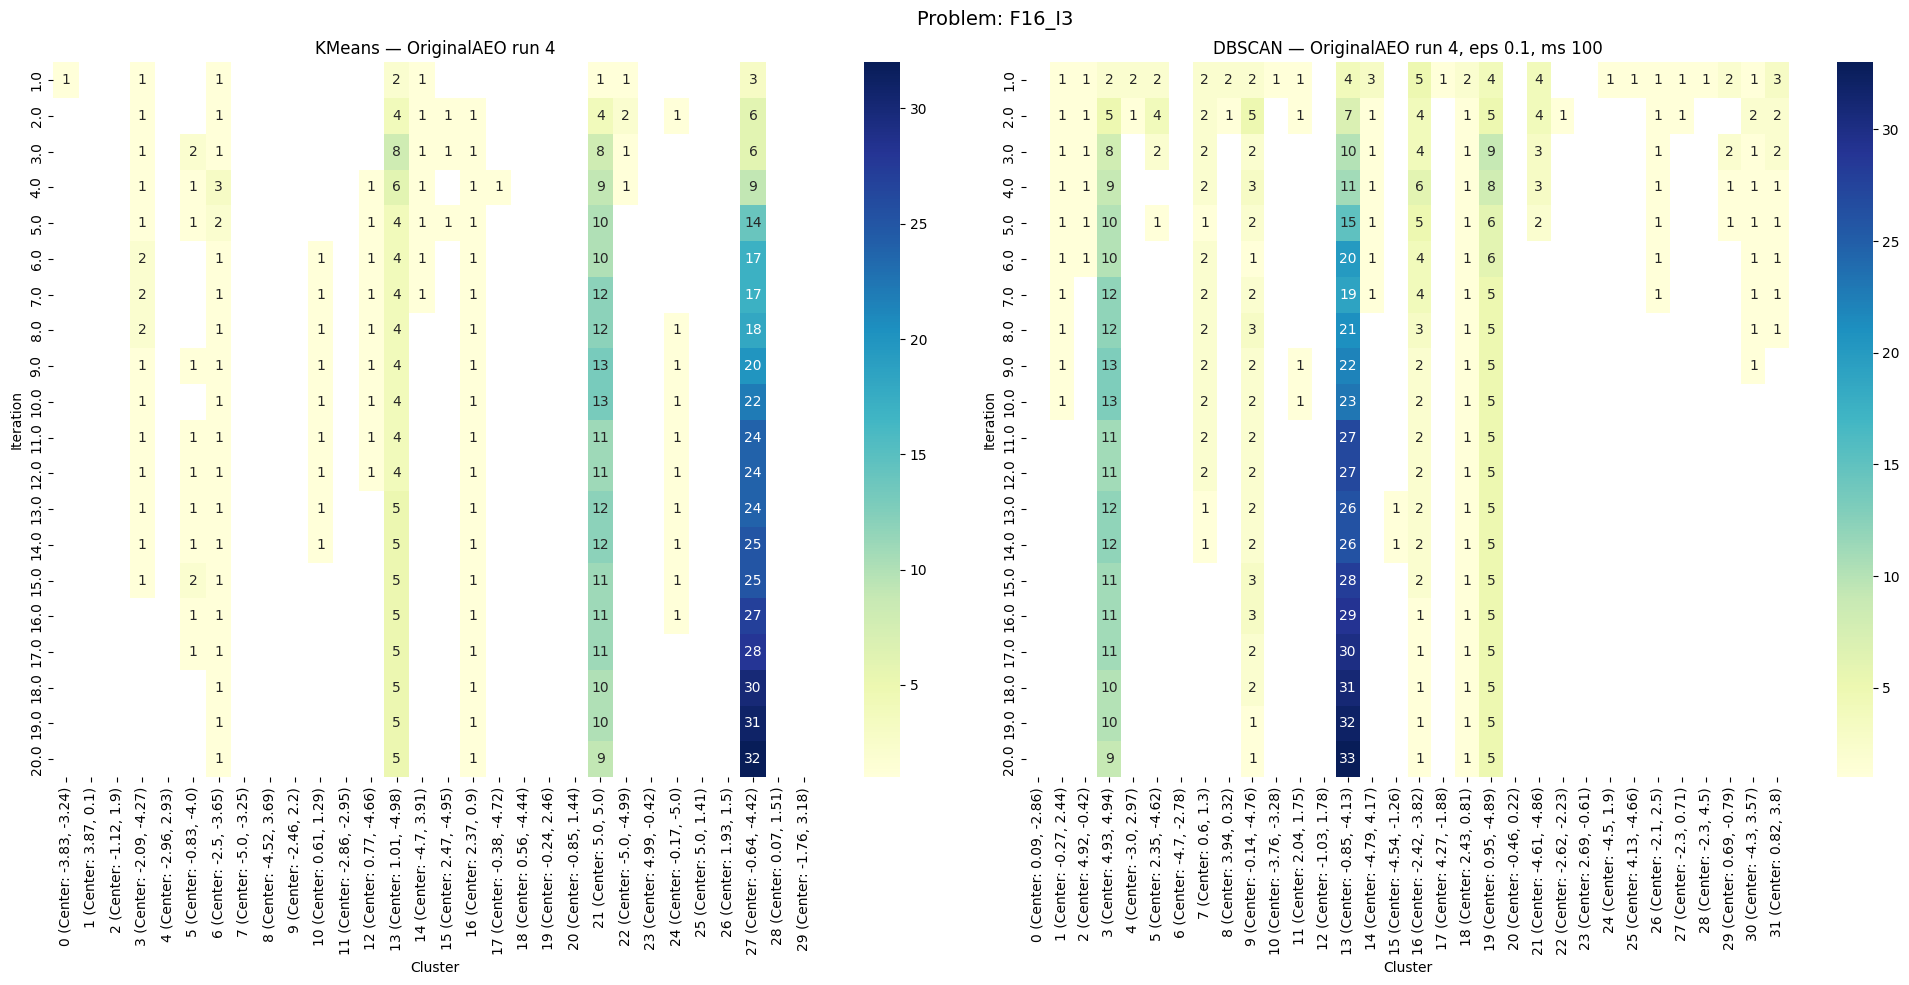

F16_I3 OriginalAEO 5


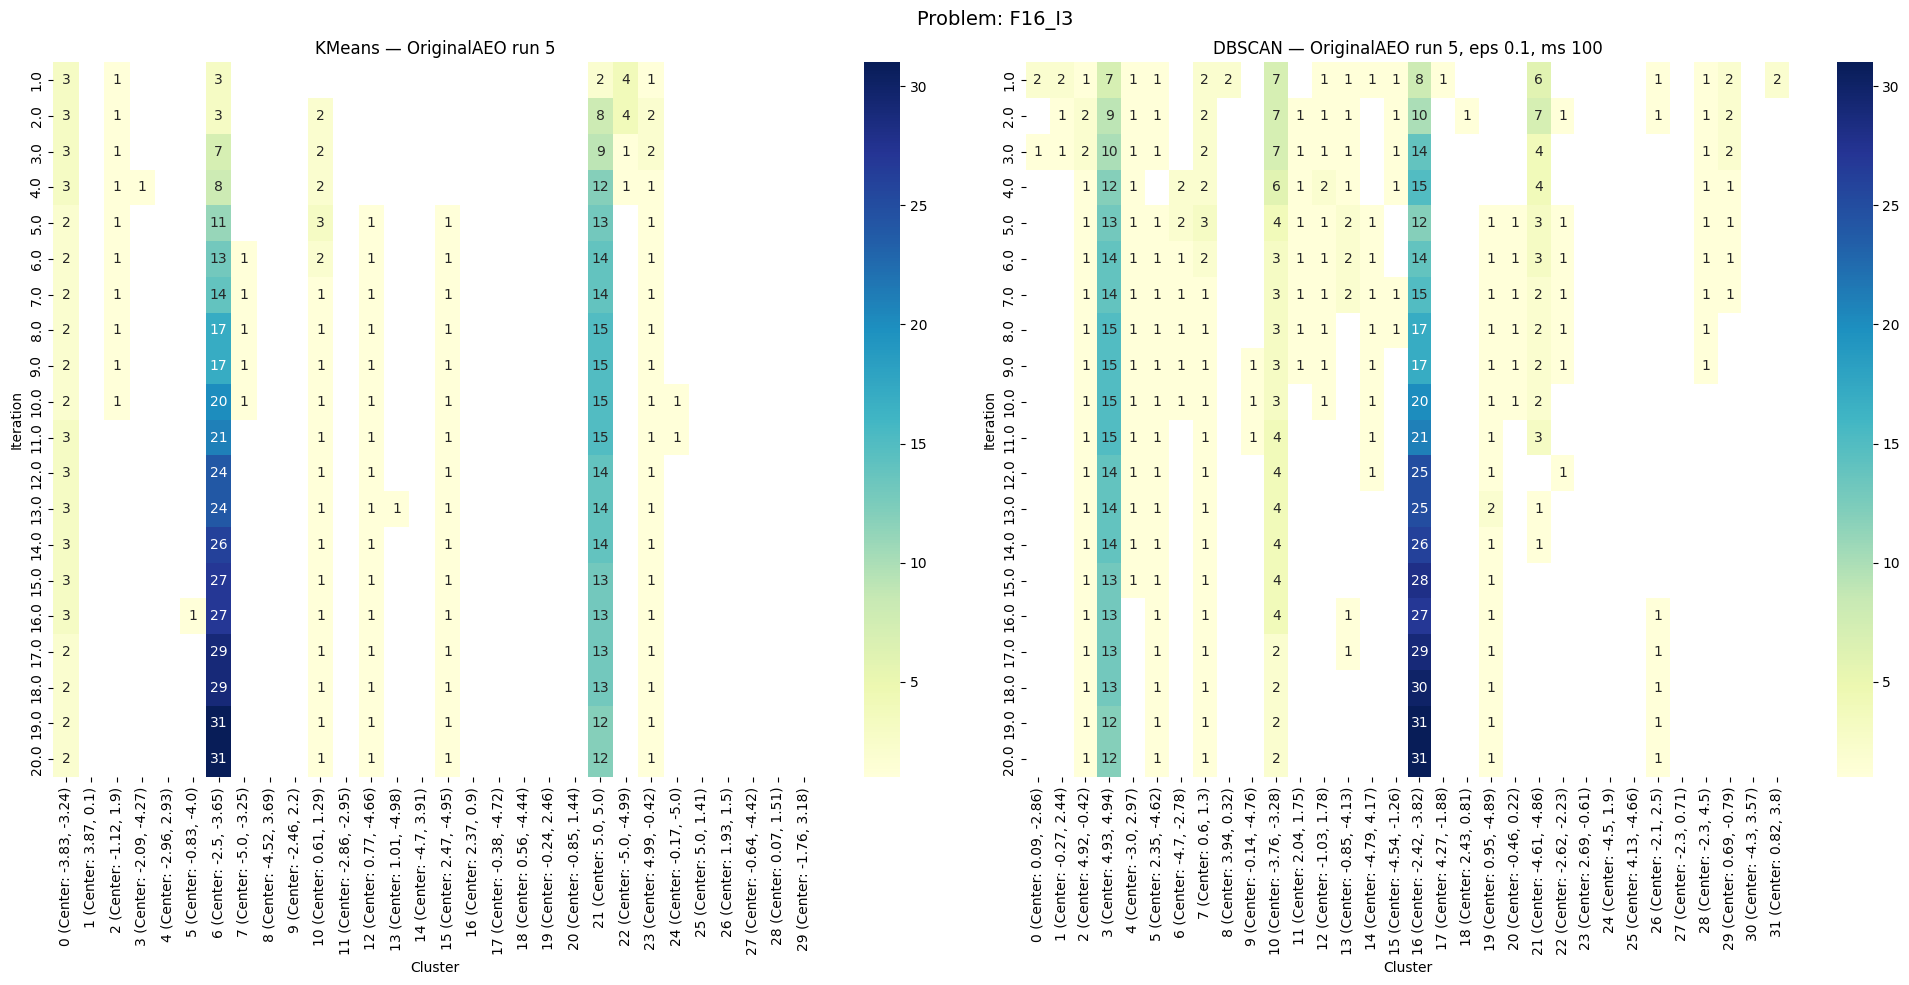

In [5]:
visualize_dbscan_kmeans([2], ["F16_I3"], ["AugmentedAEO", "OriginalAEO"], [1, 2, 3, 4, 5], plot_y=False, data_dir1=DATA_DIR_DBSCAN, data_dir2=DATA_DIR_KMEANS)

F16_I3 HI_WOA 1


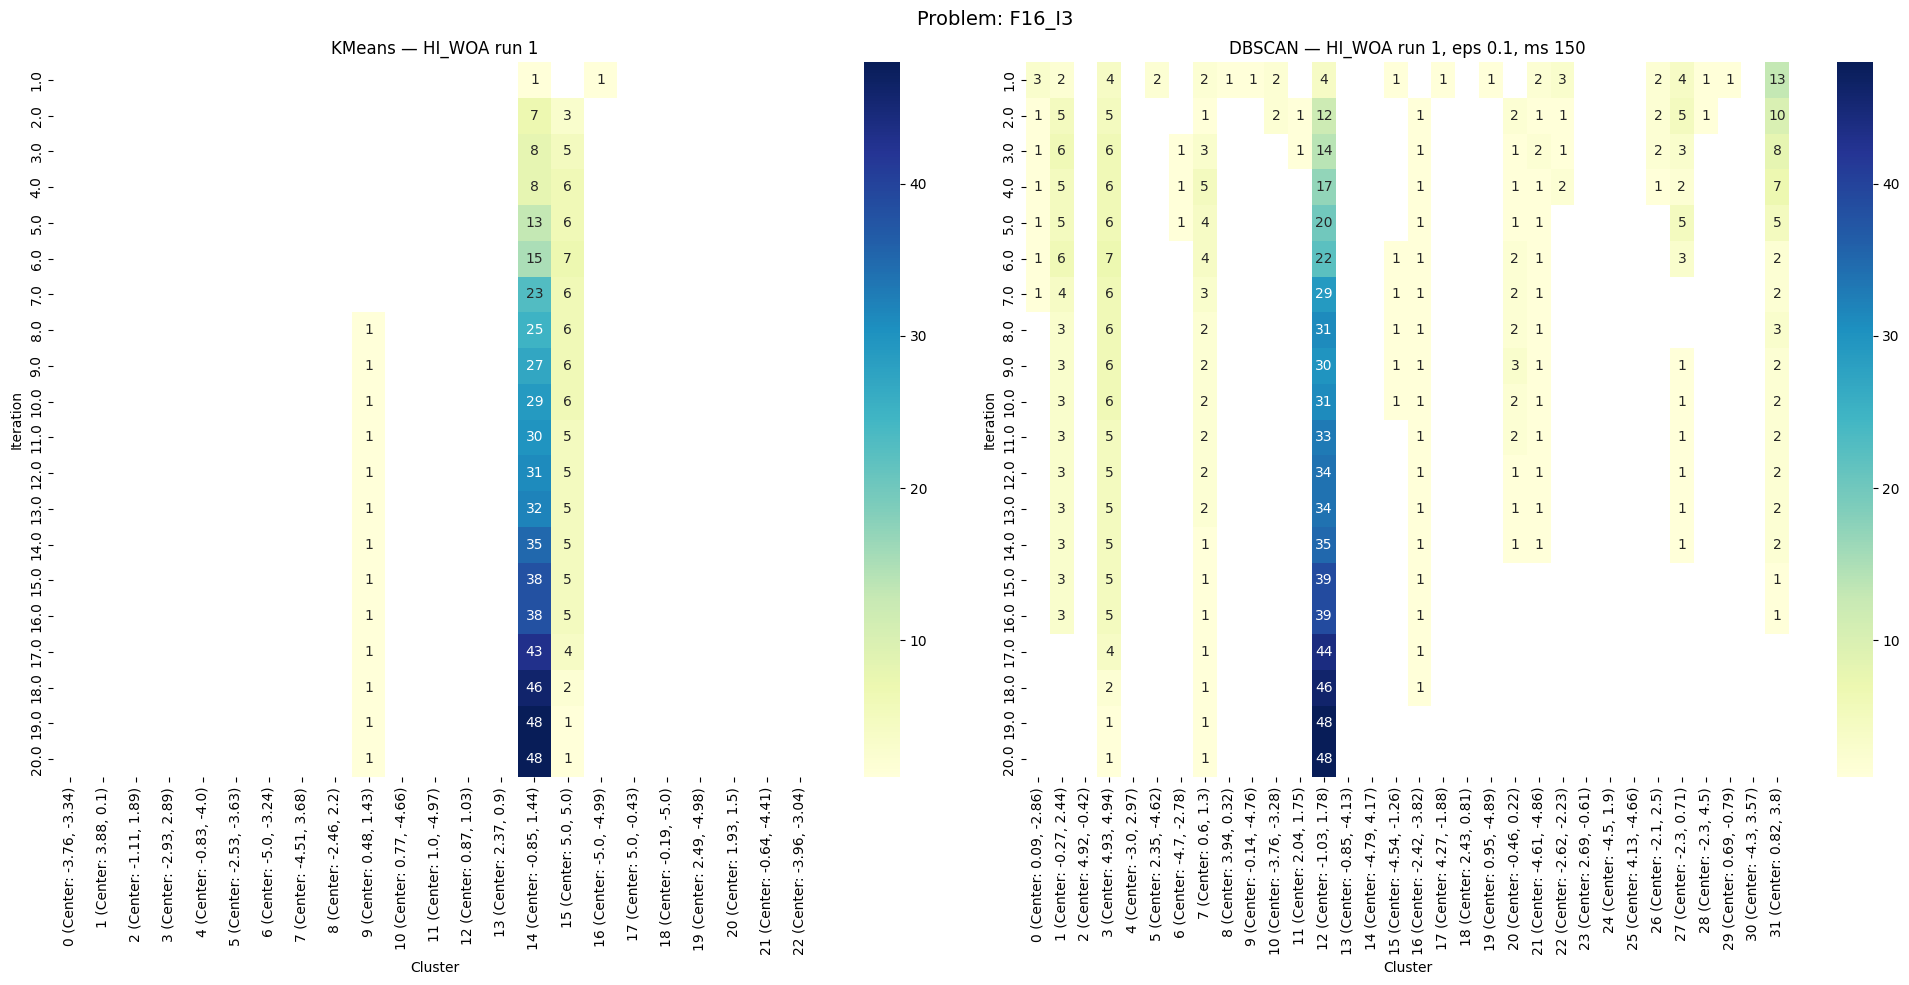

F16_I3 HI_WOA 2


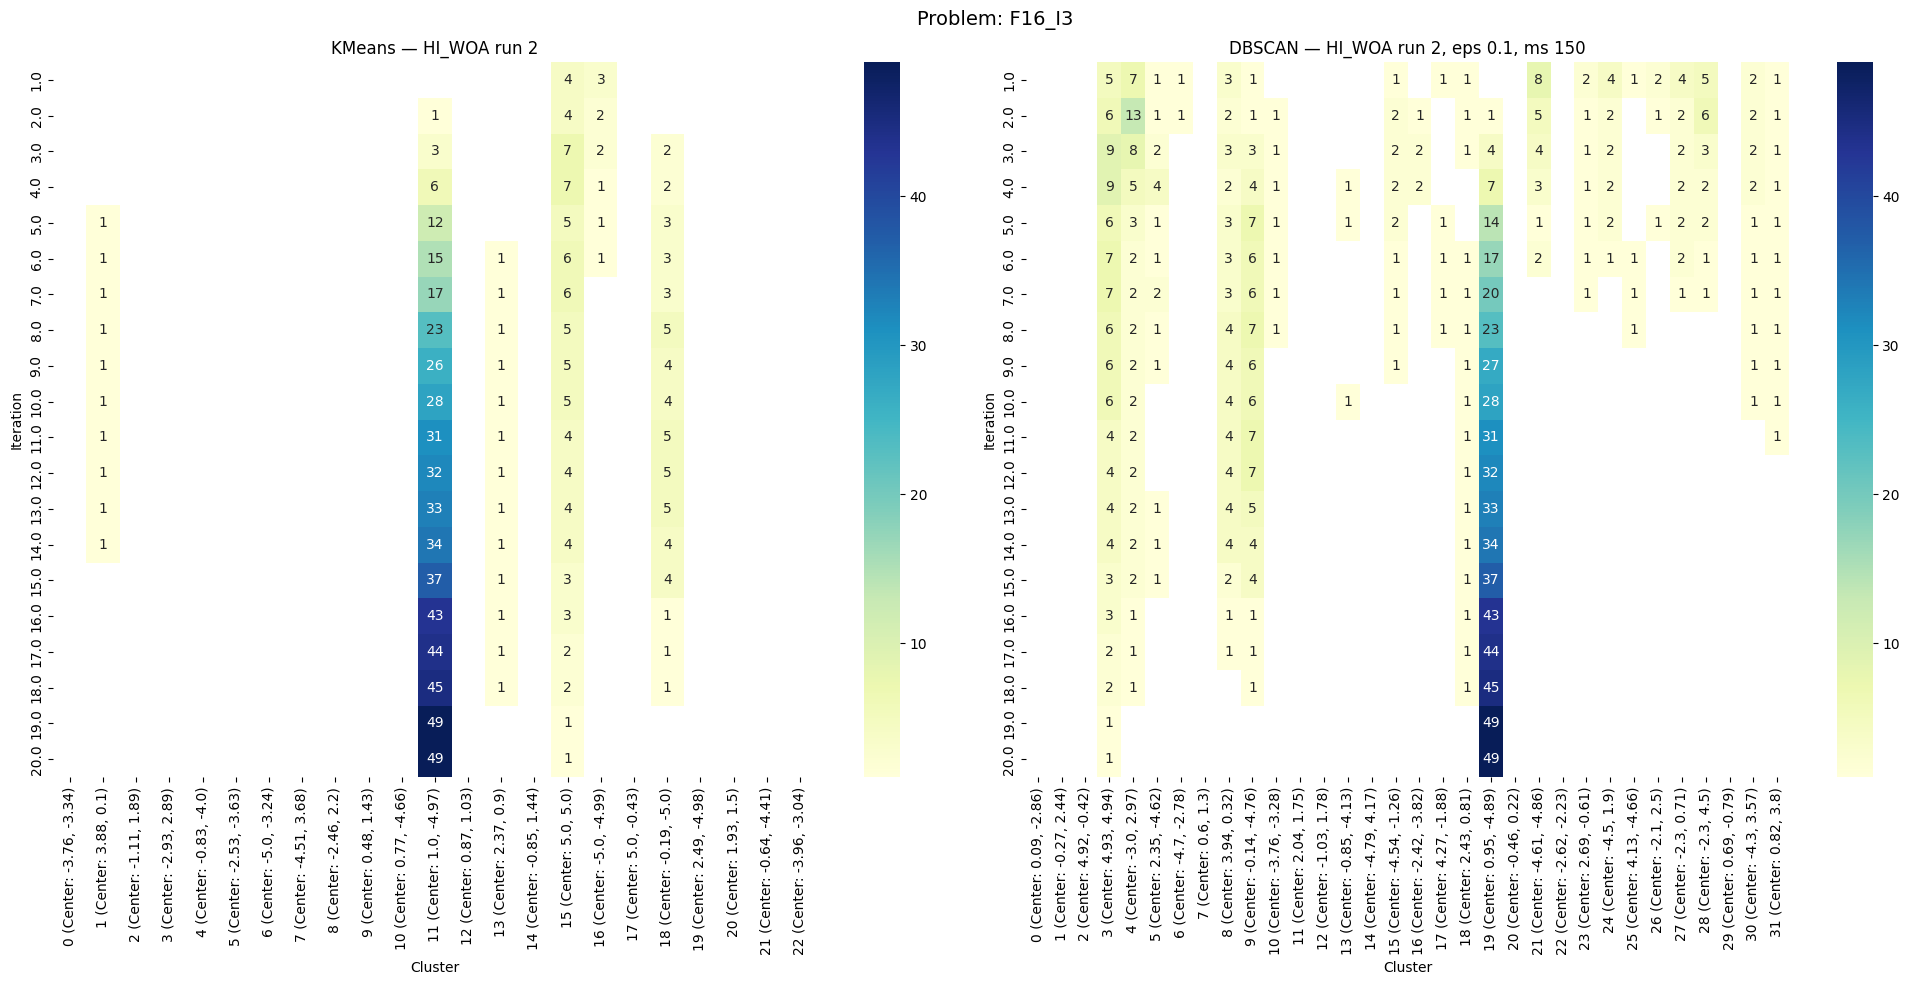

F16_I3 HI_WOA 3


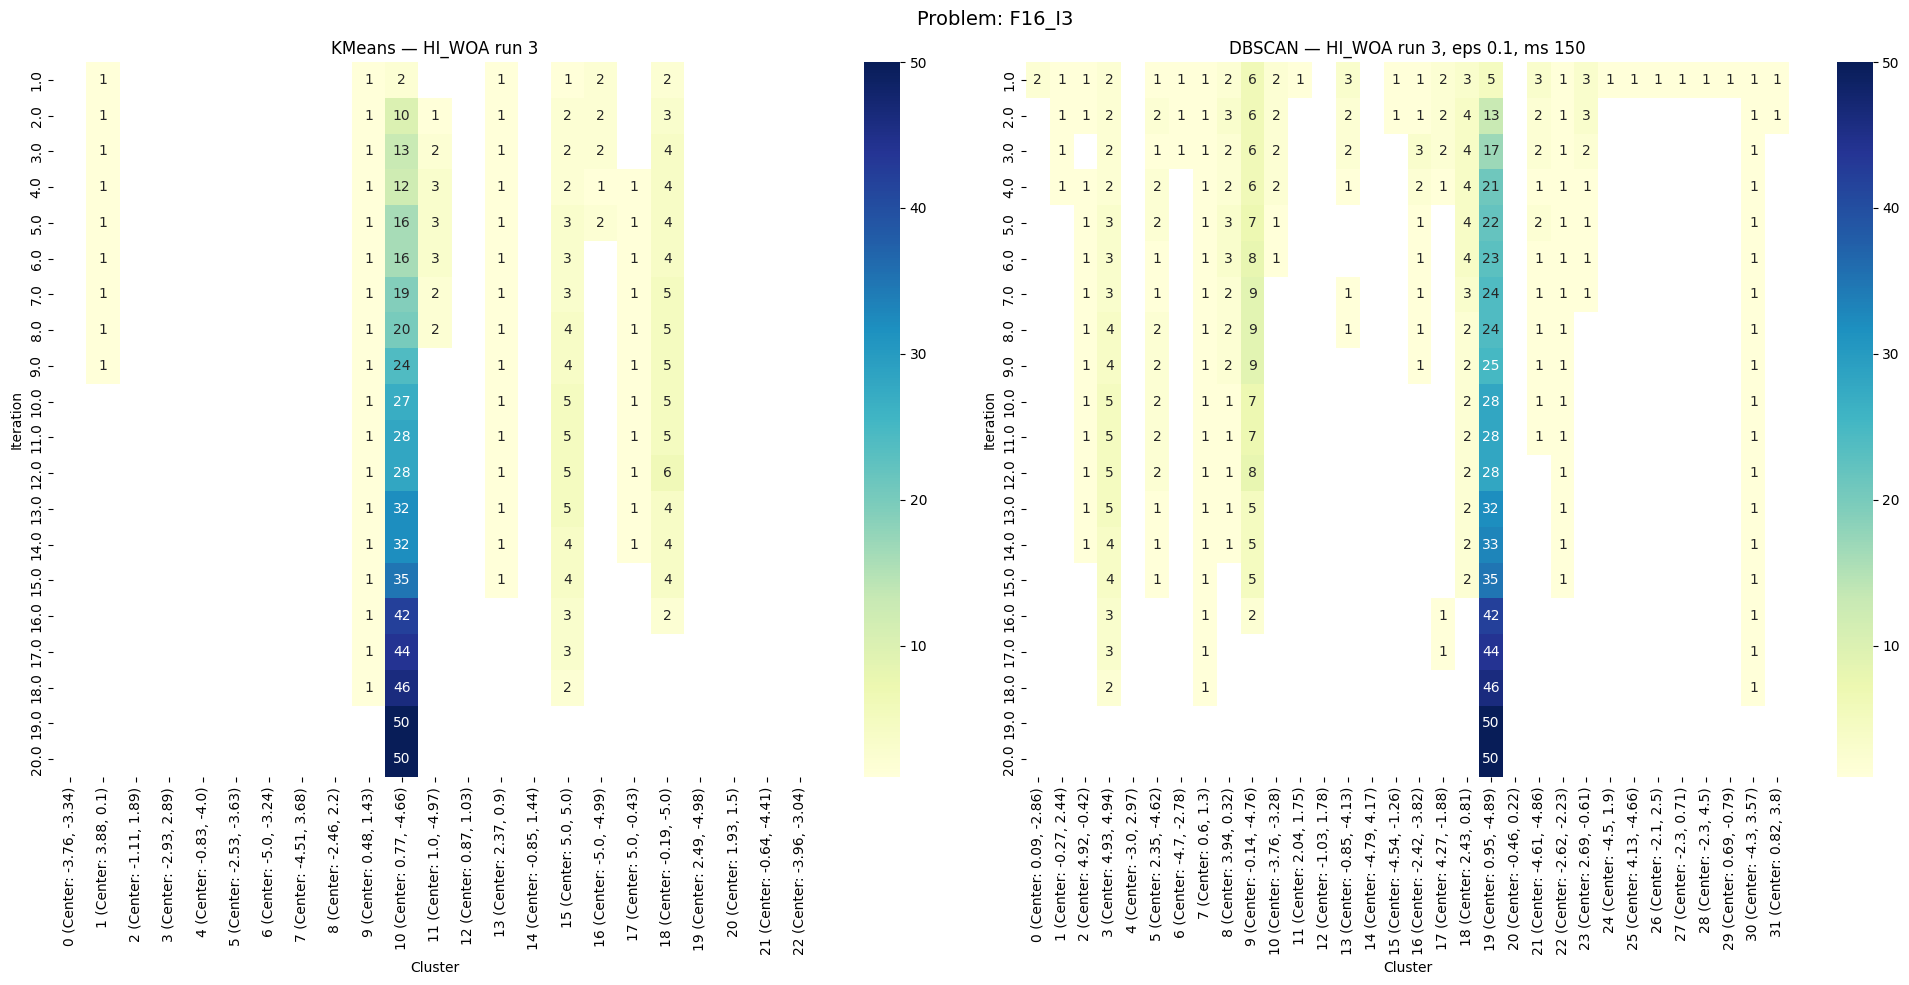

F16_I3 HI_WOA 4


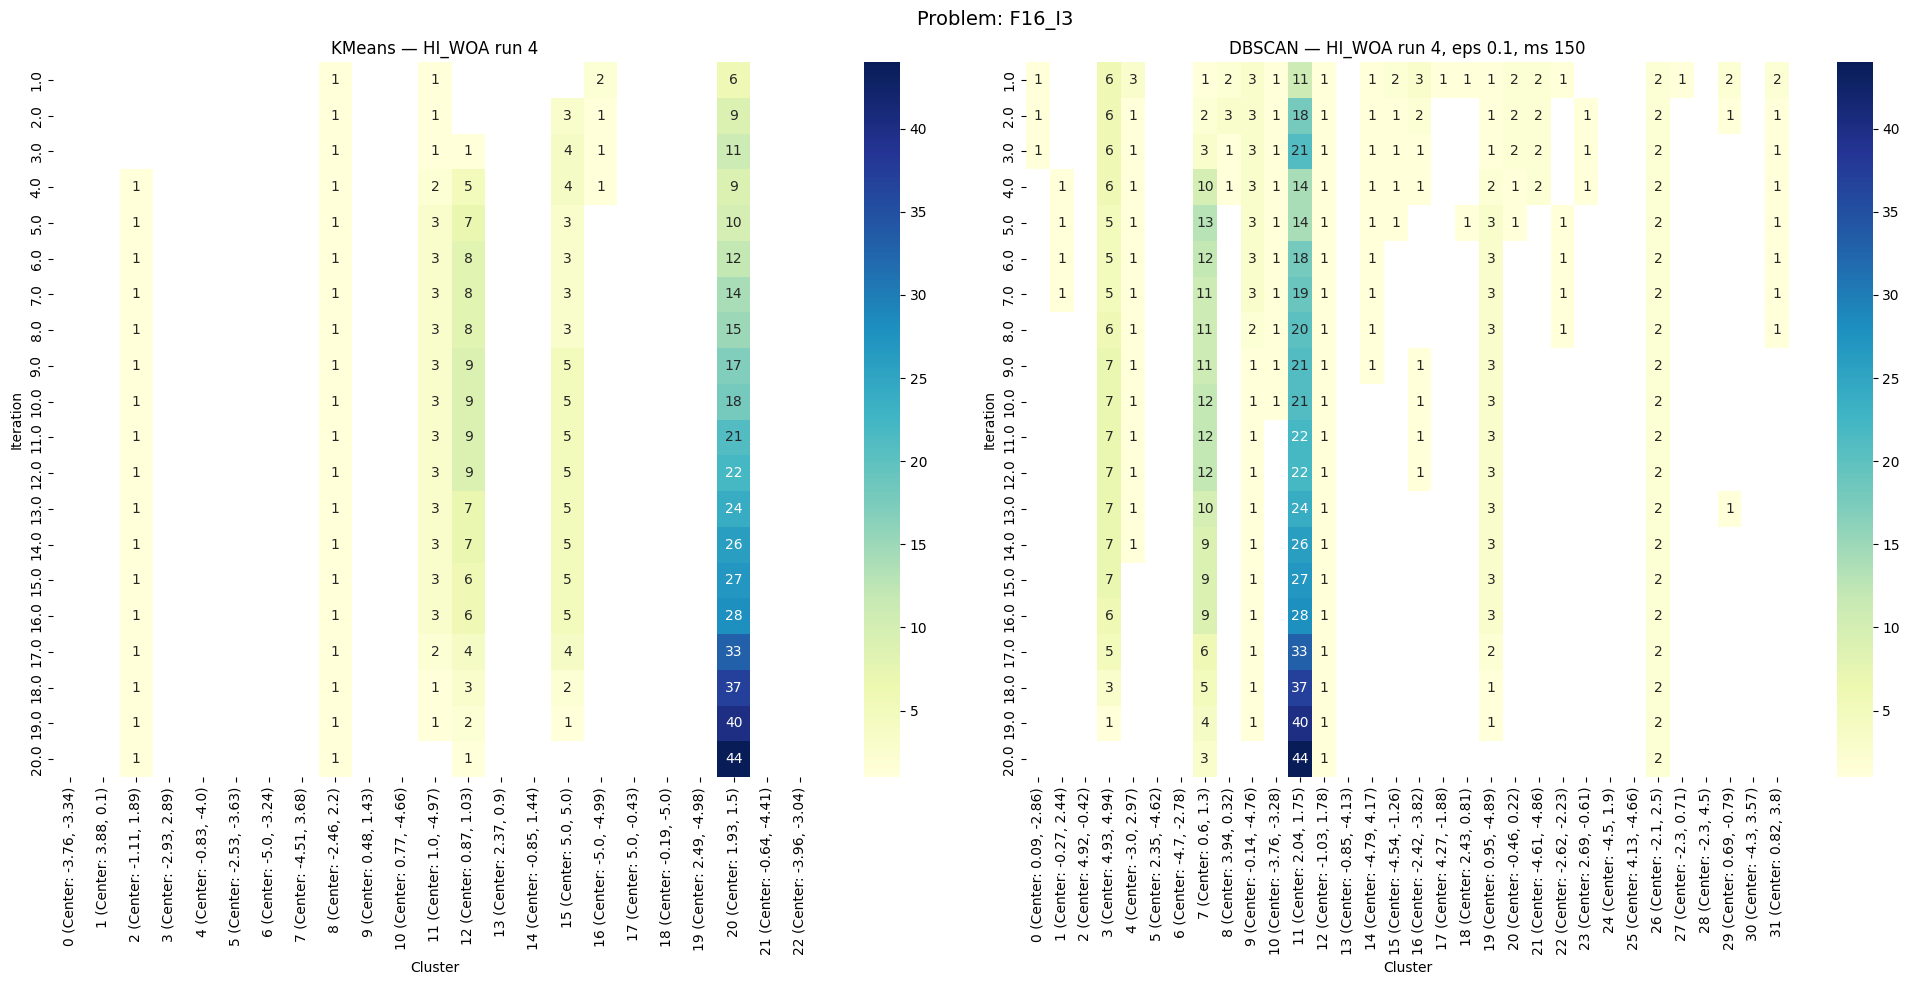

F16_I3 HI_WOA 5


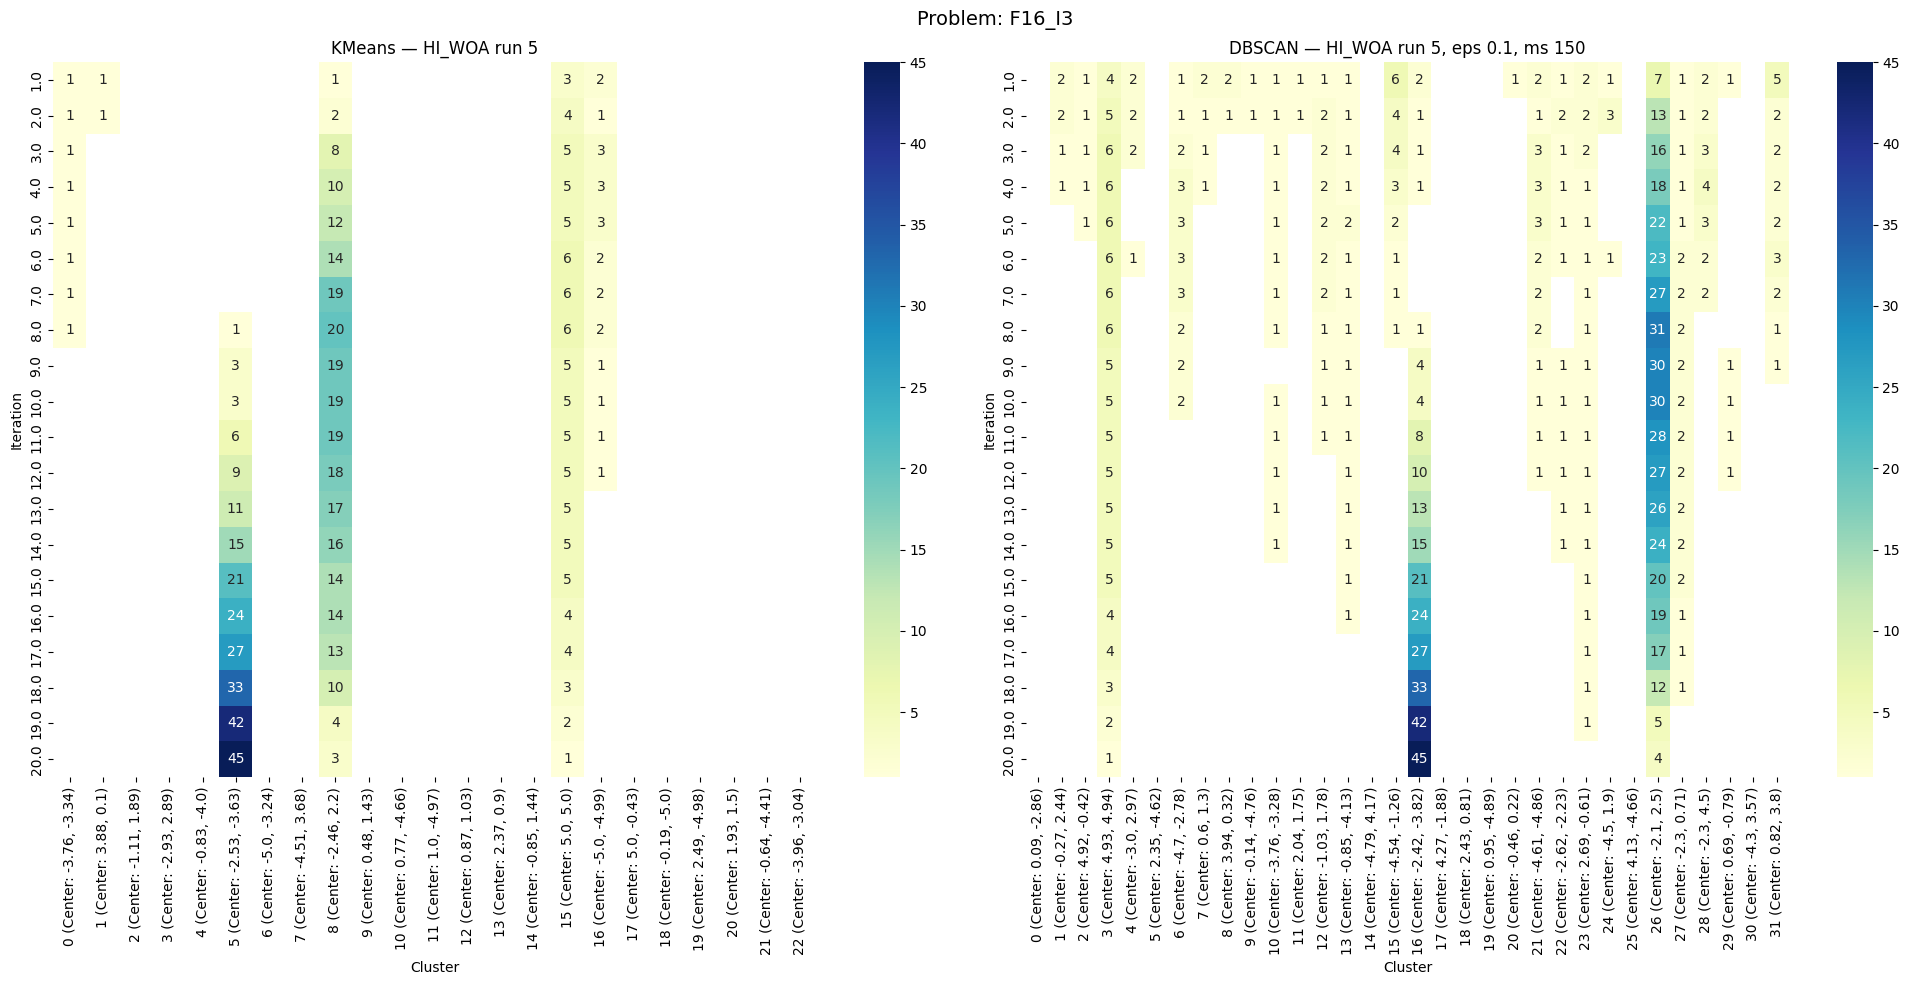

F16_I3 OriginalWOA 1


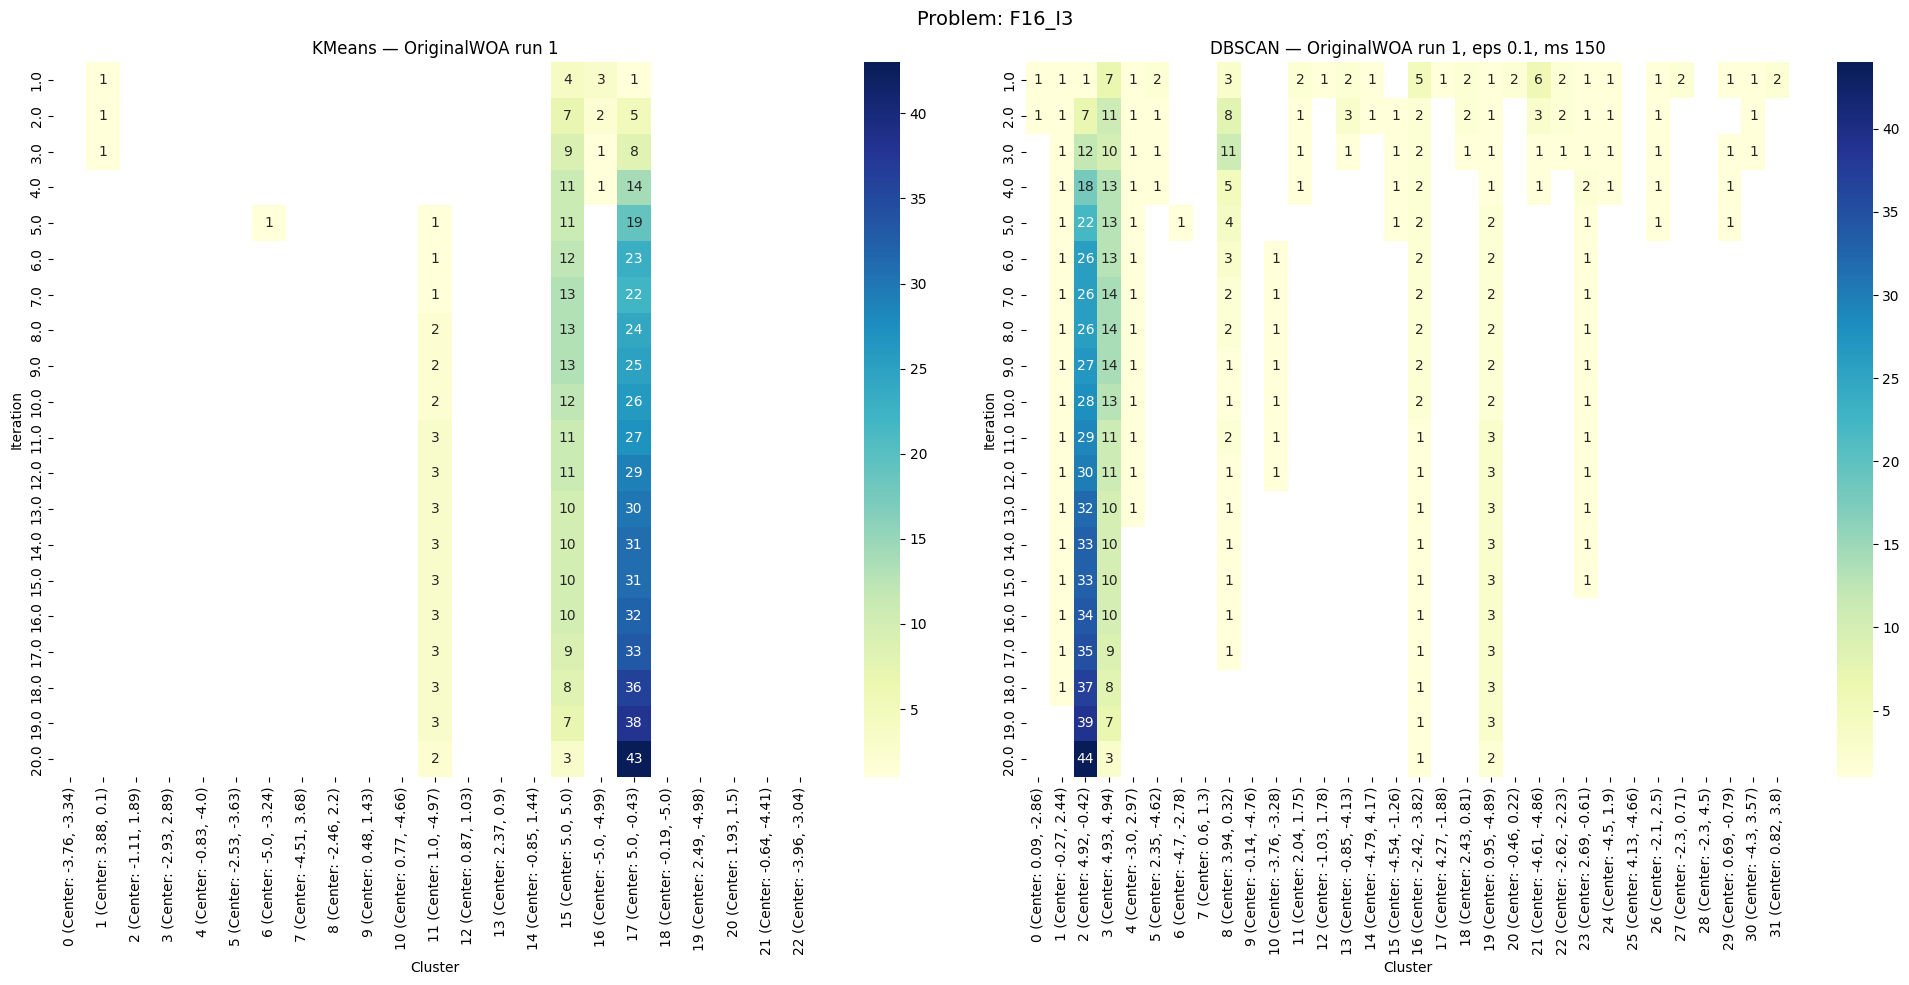

F16_I3 OriginalWOA 2


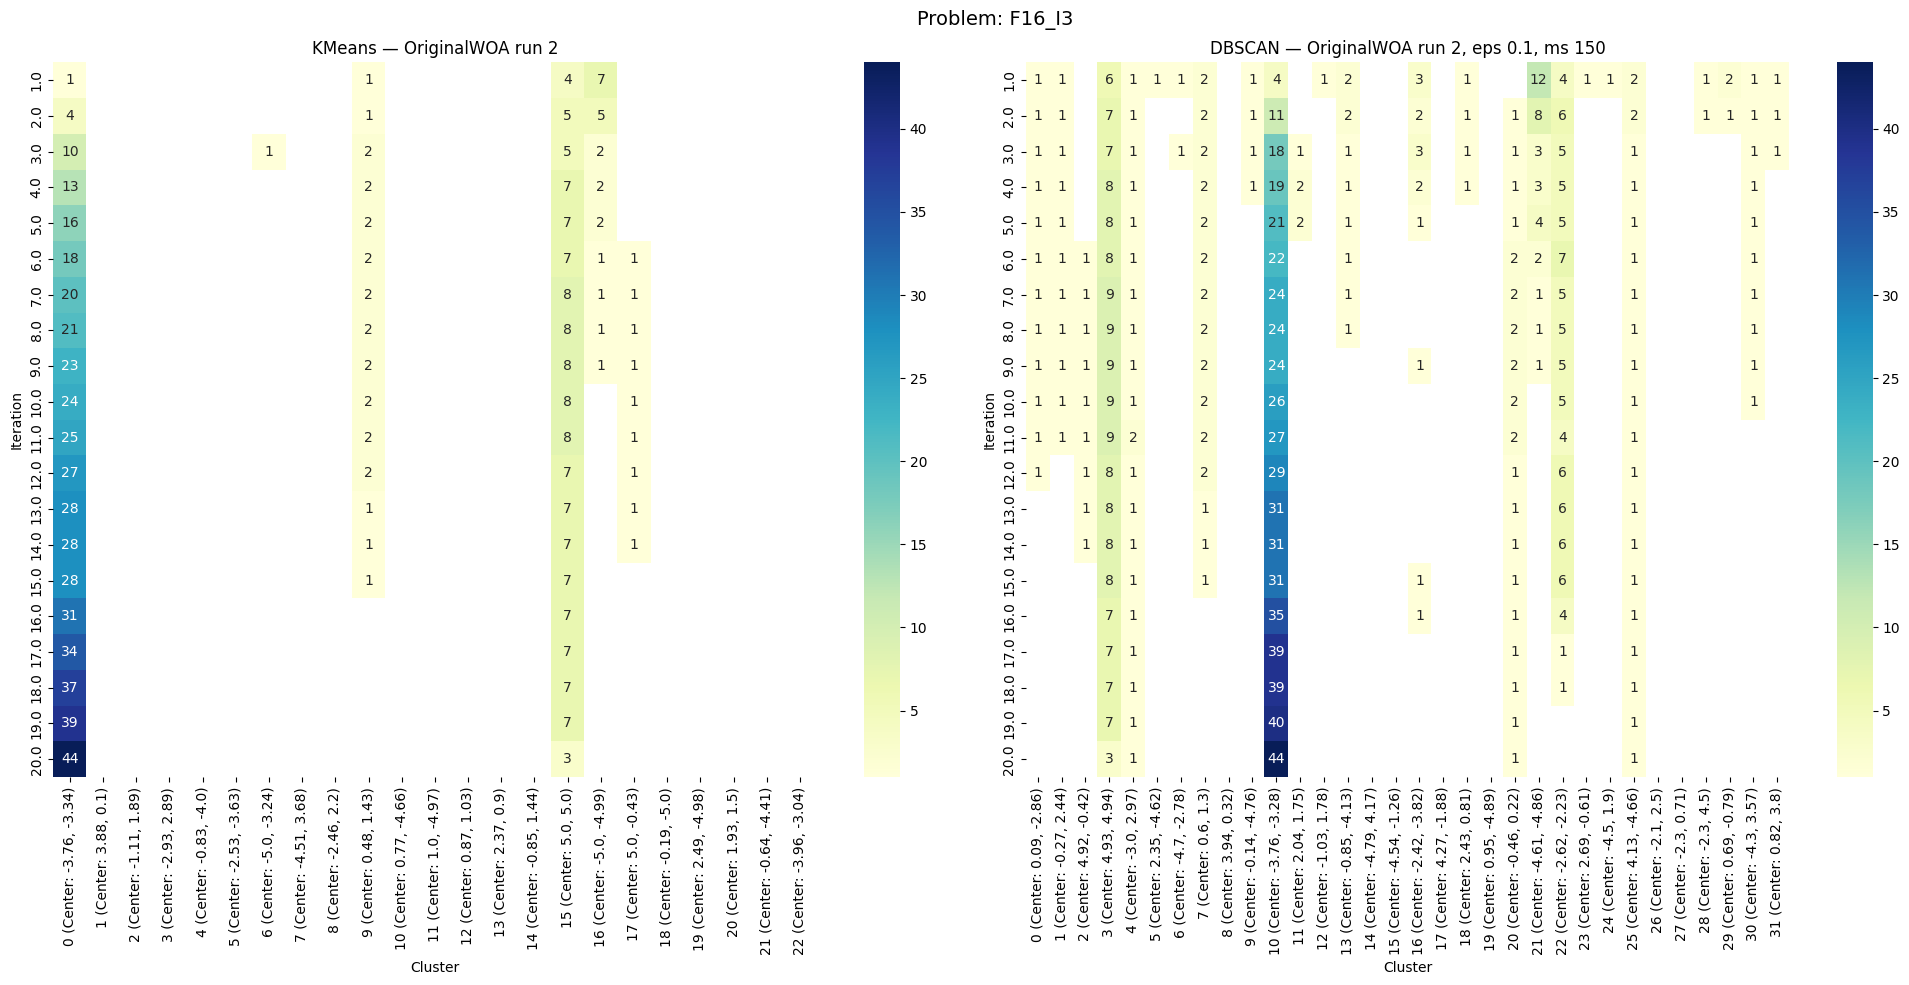

F16_I3 OriginalWOA 3


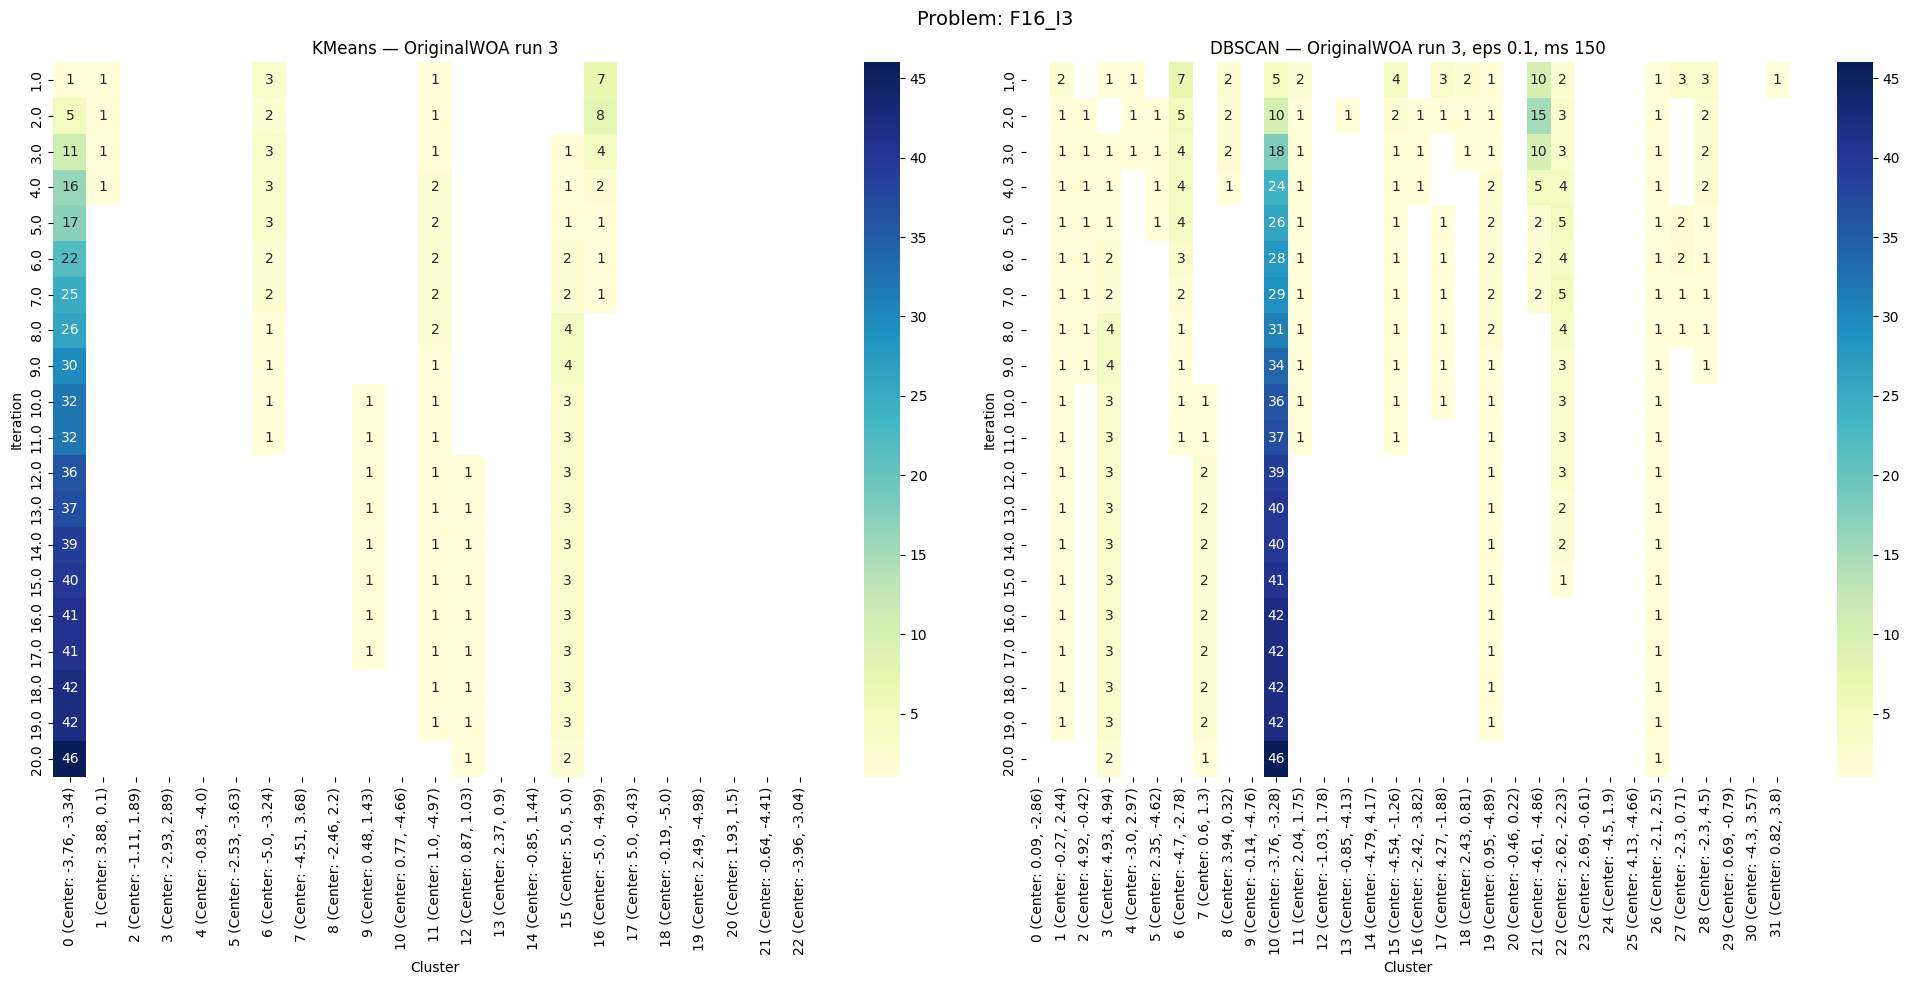

F16_I3 OriginalWOA 4


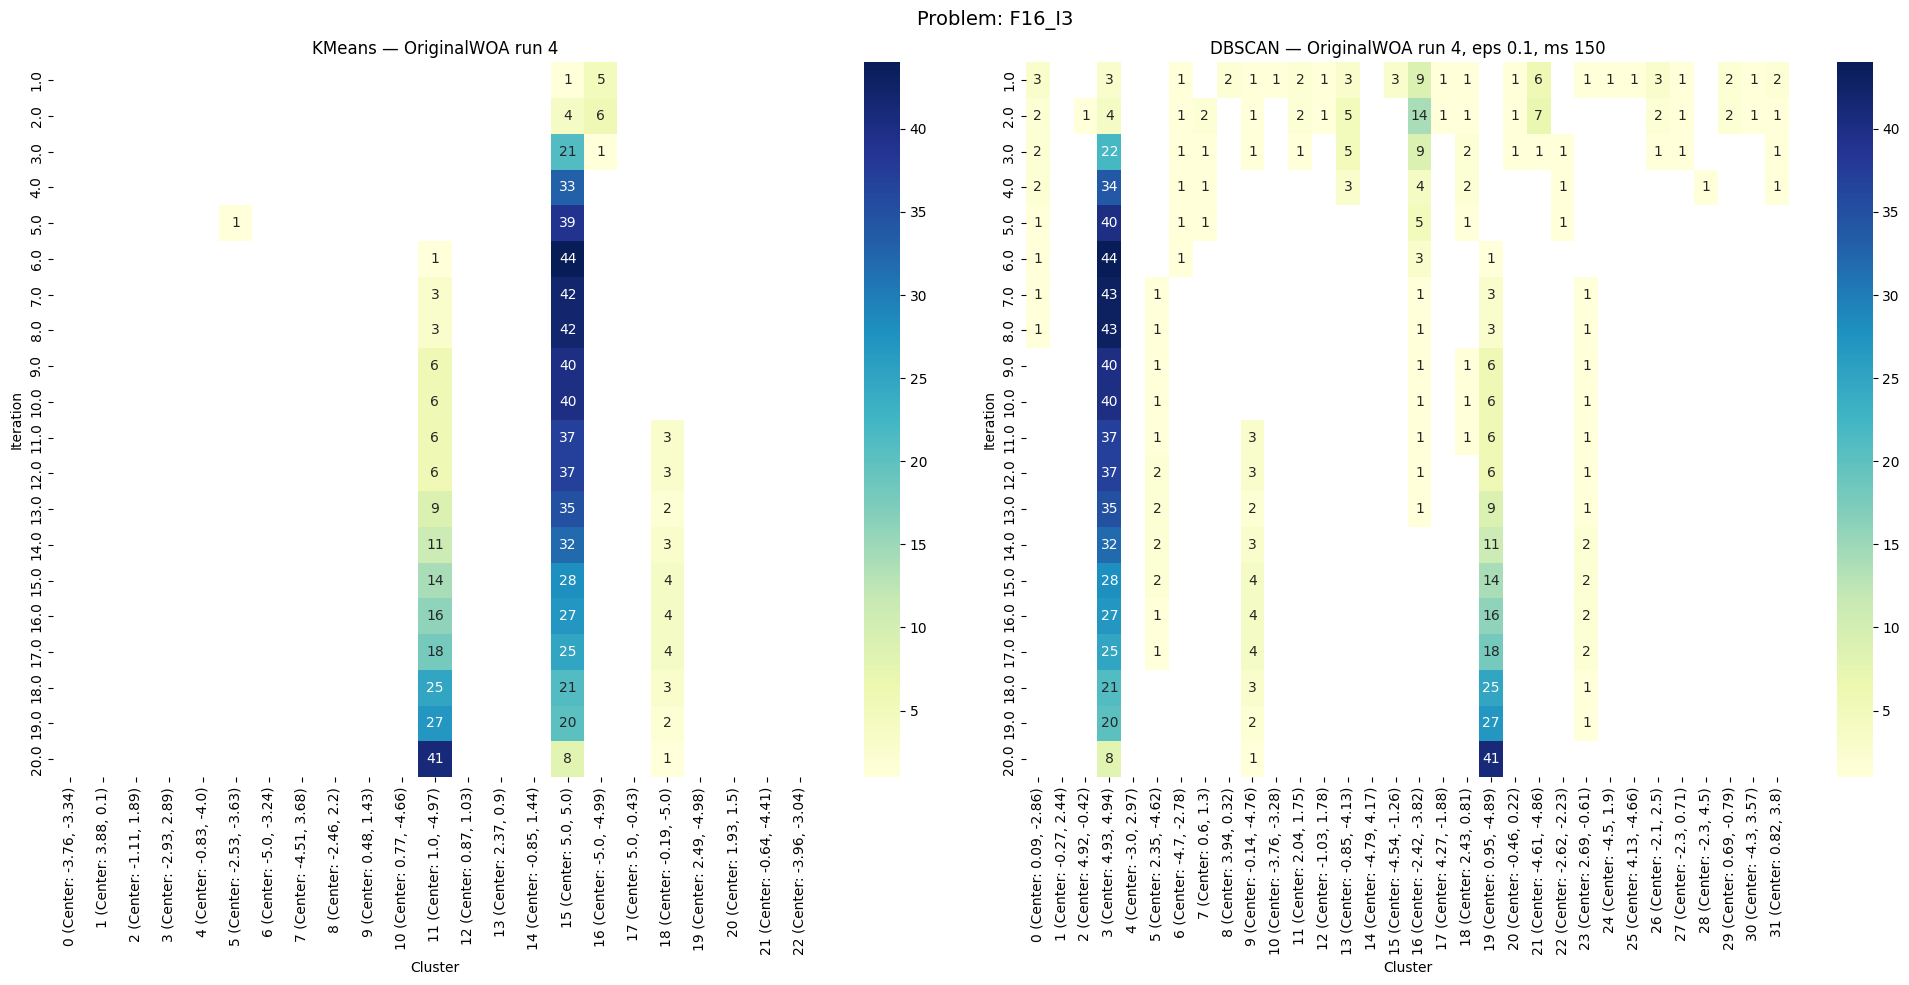

F16_I3 OriginalWOA 5


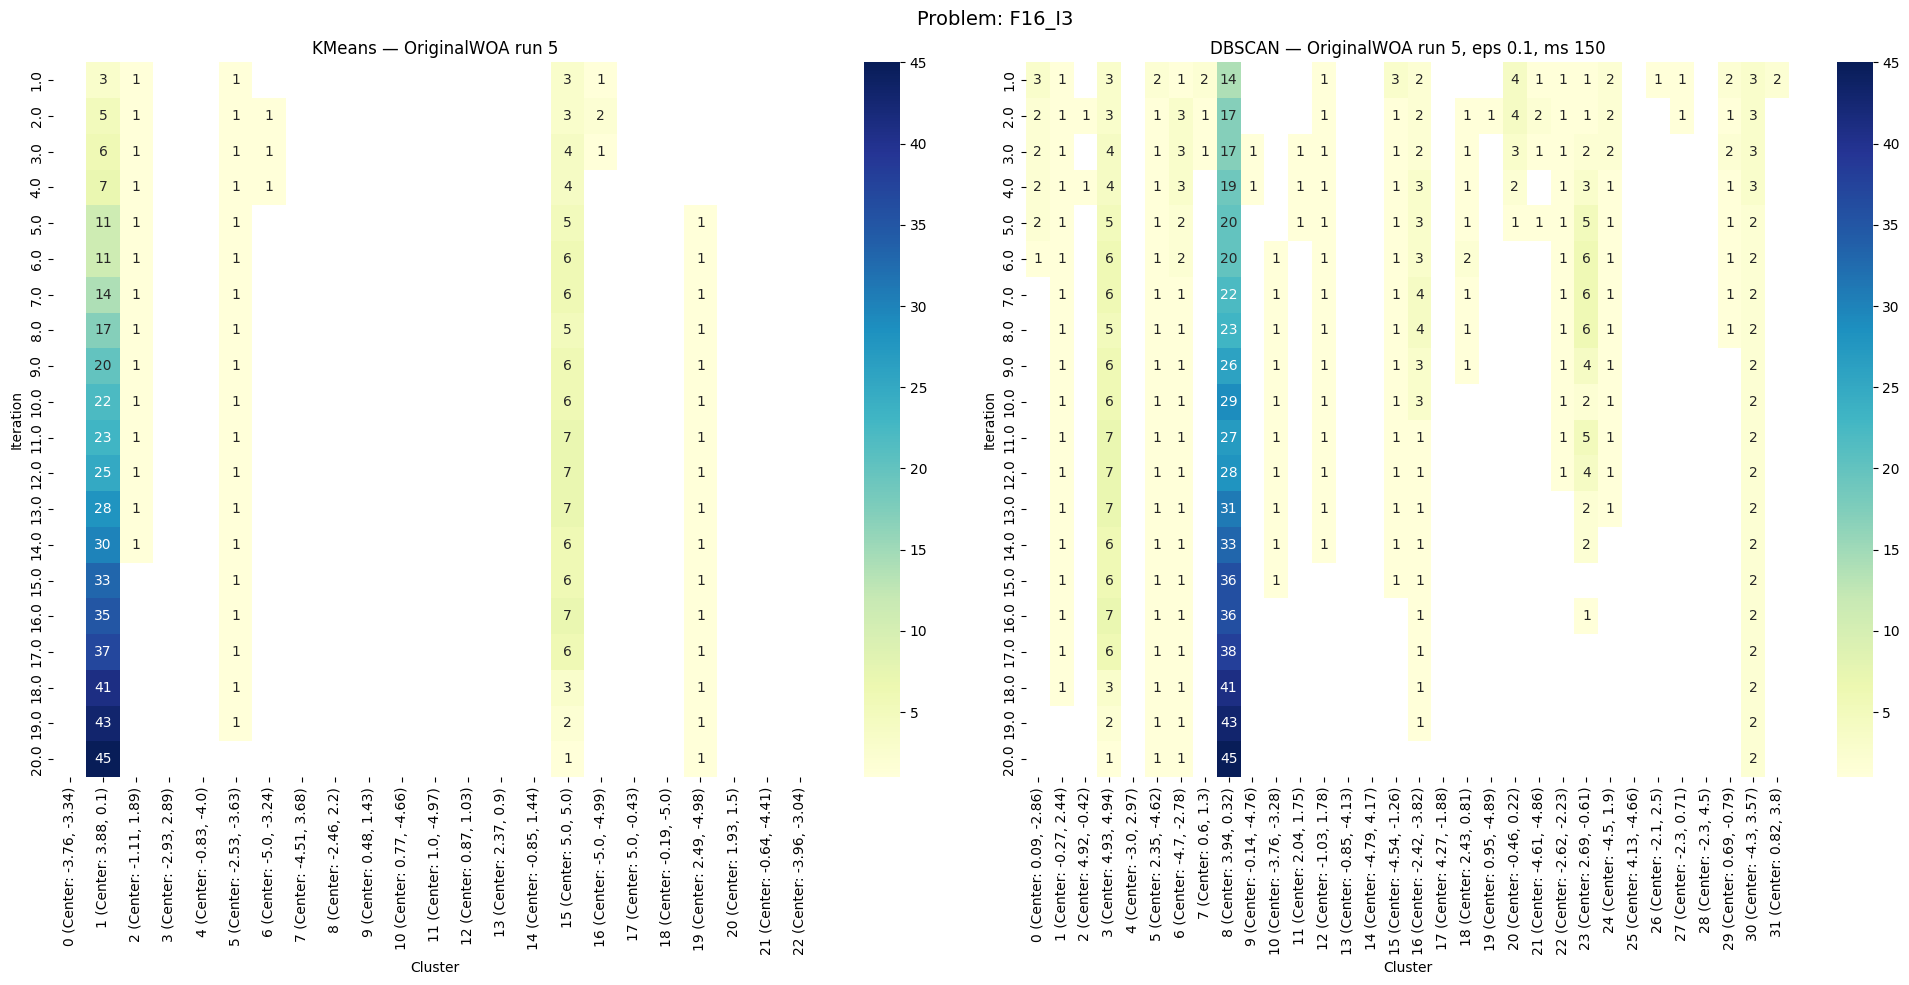

In [7]:
visualize_dbscan_kmeans([2], ["F16_I3"], ["HI_WOA", "OriginalWOA"], [1, 2, 3, 4, 5], plot_y=False, data_dir1=DATA_DIR_DBSCAN, data_dir2=DATA_DIR_KMEANS, eps=0.1, ms=150)


In [8]:
def compare_similarity_methods(dimensions, data_dir_kmeans, data_dir_dbscan, save=False, output_dir='similarity_comparison', eps=0.1, ms=100):
    
    os.makedirs(output_dir, exist_ok=True)

    def compute_similarities(directory):
        """Load cluster distributions and compute pairwise cosine similarities."""
        trajectory_similarities = []
        for file in tqdm(os.listdir(directory)):
            file_loc = f'{directory}/{file}'
            if not os.path.isfile(file_loc):
                continue
            df = pd.read_csv(file_loc, index_col=[0, 1, 2])
            d_algorithm_run = df.unstack(level=-1).dropna()
            d_algorithm_run = pd.DataFrame(
                MinMaxScaler().fit_transform(d_algorithm_run),
                index=d_algorithm_run.index,
                columns=d_algorithm_run.columns
            ).dropna()
            cs = pd.DataFrame(
                cosine_similarity(d_algorithm_run),
                index=d_algorithm_run.index,
                columns=d_algorithm_run.index
            )
            c = (
                cs.reset_index()
                  .rename(columns={'algorithm': 'algorithm2', 'run': 'run2'})
                  .melt(
                      id_vars=[('algorithm2', ''), ('run2', '')],
                      value_vars=list(cs.columns)
                  )
                  .rename(columns={('algorithm2', ''): 'algorithm2', ('run2', ''): 'run2'})
            )
            c['run'] = c['run'].astype(int)
            c['run2'] = c['run2'].astype(int)
            trajectory_similarities.append(c.assign(problem=file.replace('.csv', '')))

        result = pd.concat(trajectory_similarities)
        result['problem_class'] = [int(tt.split('_')[0].replace('F', '')) for tt in result['problem']]
        result['instance'] = [int(tt.split('_')[1].replace('I', '')) for tt in result['problem']]
        return result

    for dimension in dimensions:
        print(f"\nDimension {dimension}")

        print("Computing KMeans similarities...")
        sim_kmeans = compute_similarities(f'{data_dir_kmeans}/cluster_distributions/dim_{dimension}')
        print("Computing DBSCAN similarities...")
        sim_dbscan = compute_similarities(f'{data_dir_dbscan}/cluster_distributions/dim_{dimension}/eps{eps}_ms{ms}/')

        # --- Plot 1: Stability heatmaps side by side ---
        # (same algorithm, different runs — how consistent is each algorithm with itself)
        fig, axes = plt.subplots(1, 2, figsize=(18, 10))

        for ax, sim, title in zip(axes, [sim_kmeans, sim_dbscan], ['KMeans', 'DBSCAN']):
            sim_per_problem = (
                sim.query('algorithm==algorithm2 and run!=run2')
                   .groupby(['problem_class', 'algorithm'])['value']
                   .mean()
            )
            pivoted = (
                sim_per_problem.reset_index()
                               .pivot(index='problem_class', columns='algorithm', values='value')
                               .sort_index()
            )
            sns.heatmap(pivoted, annot=True, fmt=".2f", cmap='YlGnBu', ax=ax, vmin=0, vmax=1)
            ax.set_title(f'{title} — Algorithm Stability per Problem (dim {dimension})')

        plt.suptitle('Algorithm Stability Comparison: KMeans vs DBSCAN', fontsize=14)
        plt.tight_layout()
        if save:
            plt.savefig(f'{output_dir}/stability_comparison_dim_{dimension}.pdf', bbox_inches='tight')
        plt.show()

        # --- Plot 2: Cross-algorithm similarity clustermaps side by side ---
        # (different algorithms, same run — how similar are algorithms to each other)
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        for ax, sim, title in zip(axes, [sim_kmeans, sim_dbscan], ['KMeans', 'DBSCAN']):
            cross_sim = (
                sim.query('run==run2')
                   .groupby(['algorithm', 'algorithm2'])['value']
                   .mean()
            )
            pivoted = (
                cross_sim.reset_index()
                         .pivot(index='algorithm', columns='algorithm2', values='value')
            )
            sns.heatmap(pivoted, annot=True, fmt=".2f", cmap='YlGnBu', ax=ax, vmin=0, vmax=1)
            ax.set_title(f'{title} — Cross-Algorithm Similarity (dim {dimension})')

        plt.suptitle('Cross-Algorithm Similarity Comparison: KMeans vs DBSCAN', fontsize=14)
        plt.tight_layout()
        if save:
            plt.savefig(f'{output_dir}/cross_similarity_comparison_dim_{dimension}.pdf', bbox_inches='tight')
        plt.show()

        # --- Plot 3: Distribution of similarity values ---
        # Shows clearly how DBSCAN inflates similarity scores vs KMeans
        fig, ax = plt.subplots(figsize=(10, 5))

        same_run_kmeans = sim_kmeans.query('run==run2 and algorithm!=algorithm2')['value']
        same_run_dbscan = sim_dbscan.query('run==run2 and algorithm!=algorithm2')['value']

        ax.hist(same_run_kmeans, bins=50, alpha=0.6, label='KMeans', color='steelblue')
        ax.hist(same_run_dbscan, bins=50, alpha=0.6, label='DBSCAN', color='coral')
        ax.set_xlabel('Cosine Similarity')
        ax.set_ylabel('Count')
        ax.set_title(f'Distribution of Pairwise Similarity Scores (dim {dimension})')
        ax.legend()

        plt.tight_layout()
        if save:
            plt.savefig(f'{output_dir}/similarity_distribution_comparison_dim_{dimension}.pdf', bbox_inches='tight')
        plt.show()

        # --- Plot 4: Clustermaps (hierarchical clustering of similarity matrix) ---
        for sim, title in zip([sim_kmeans, sim_dbscan], ['KMeans', 'DBSCAN']):
            cross_sim = (
                sim.query('run==run2')
                   .groupby(['algorithm', 'algorithm2'])['value']
                   .mean()
            )
            pivoted = (
                cross_sim.reset_index()
                         .pivot(index='algorithm', columns='algorithm2', values='value')
            )
            sns.set_theme(font_scale=1.2)
            g = sns.clustermap(pivoted, annot=True, fmt=".2f", cmap='YlGnBu', figsize=(8, 8), vmin=0, vmax=1)
            g.figure.suptitle(f'{title} — Similarity Clustermap (dim {dimension})', y=1.02)
            
            if save:
                g.figure.savefig(
                    f'{output_dir}/clustermap_{title.lower()}_dim_{dimension}.pdf',
                    bbox_inches='tight'
                )
            plt.show()
            sns.set_theme(font_scale=1)


Dimension 2
Computing KMeans similarities...


100%|██████████| 120/120 [00:02<00:00, 50.51it/s]


Computing DBSCAN similarities...


100%|██████████| 120/120 [00:01<00:00, 76.20it/s]


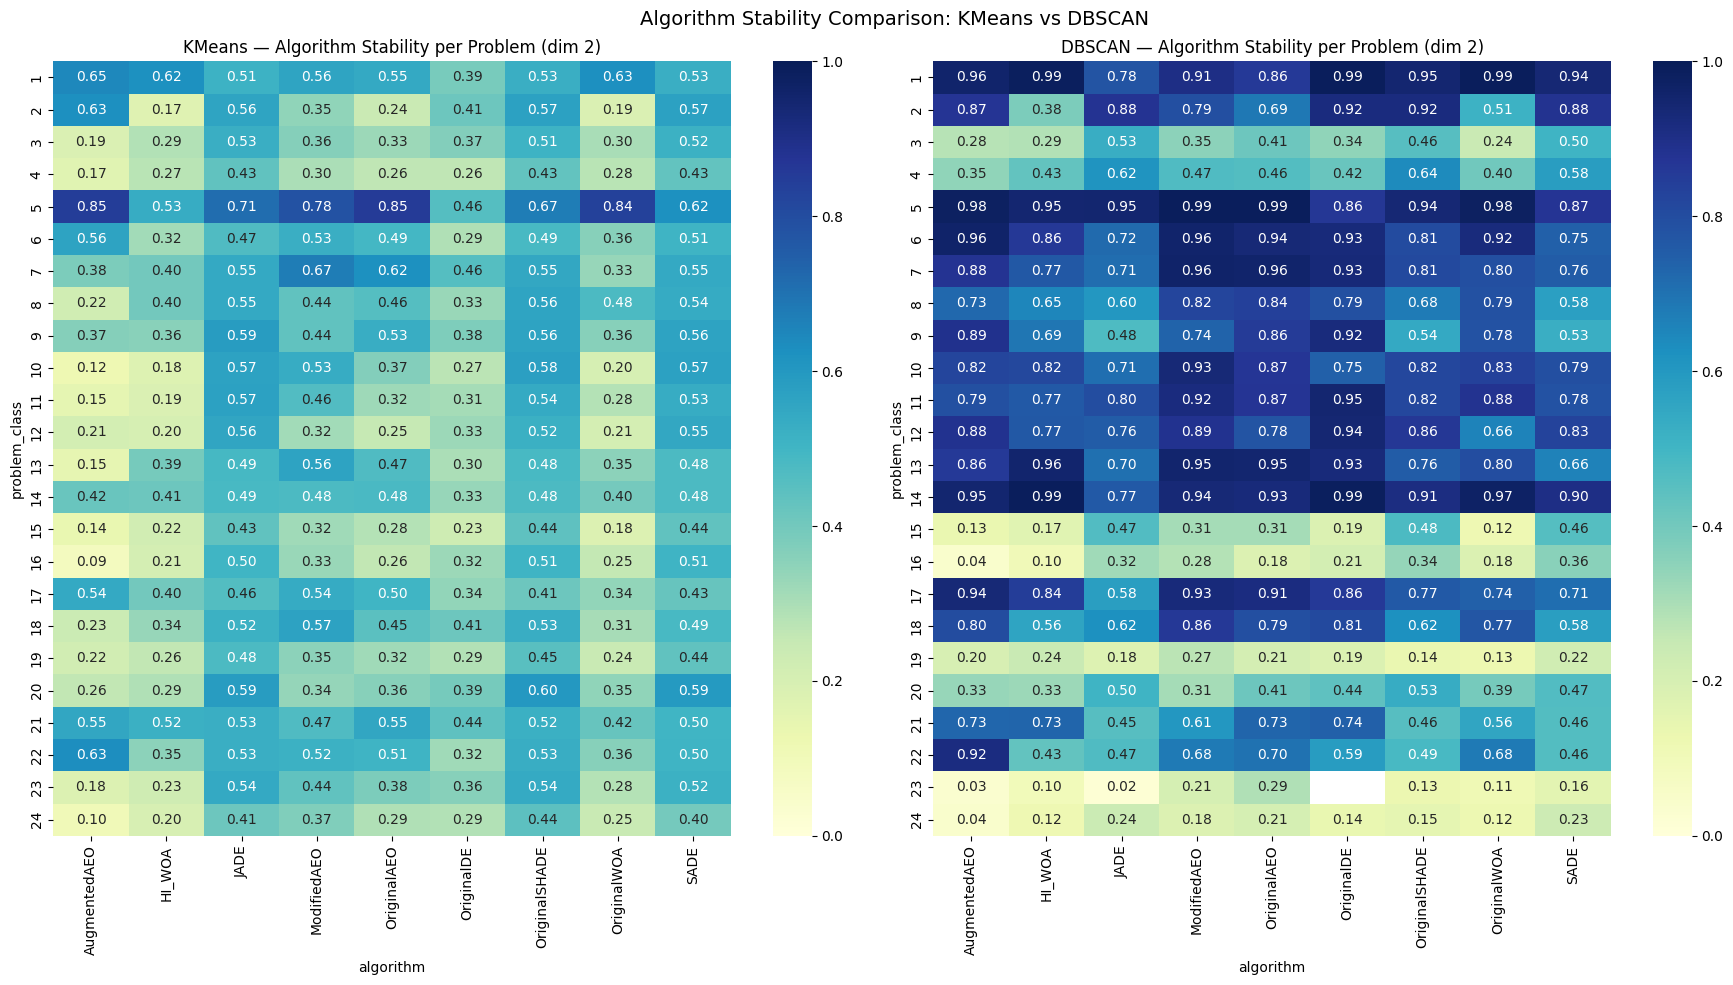

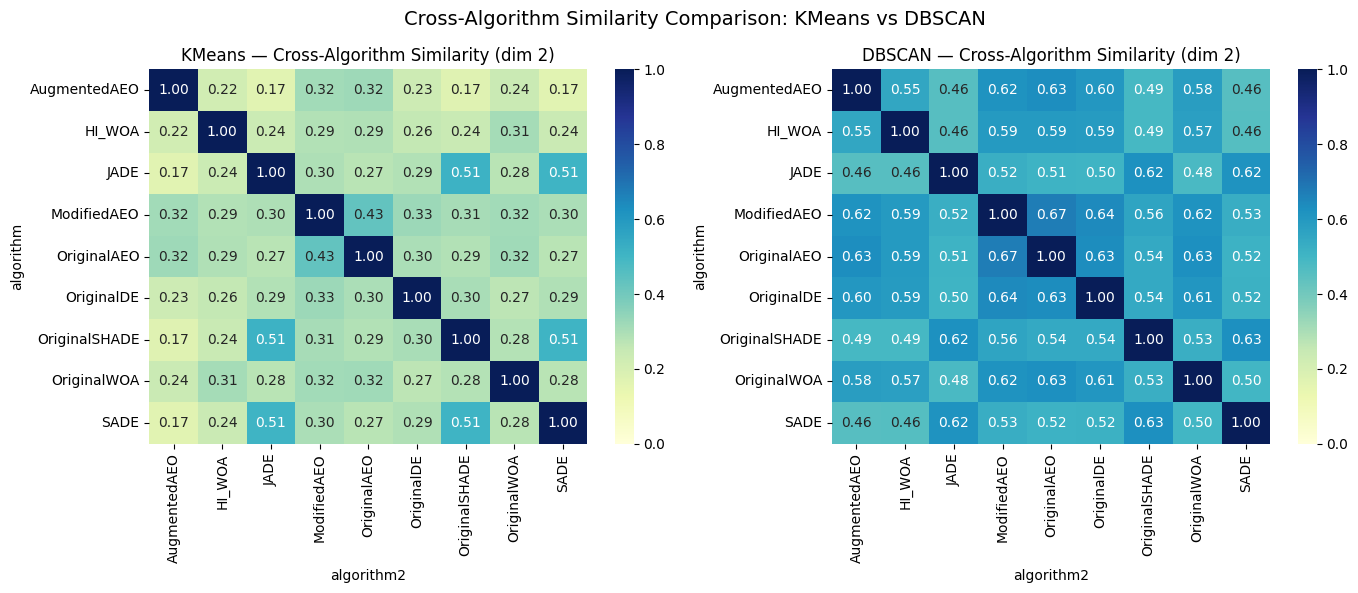

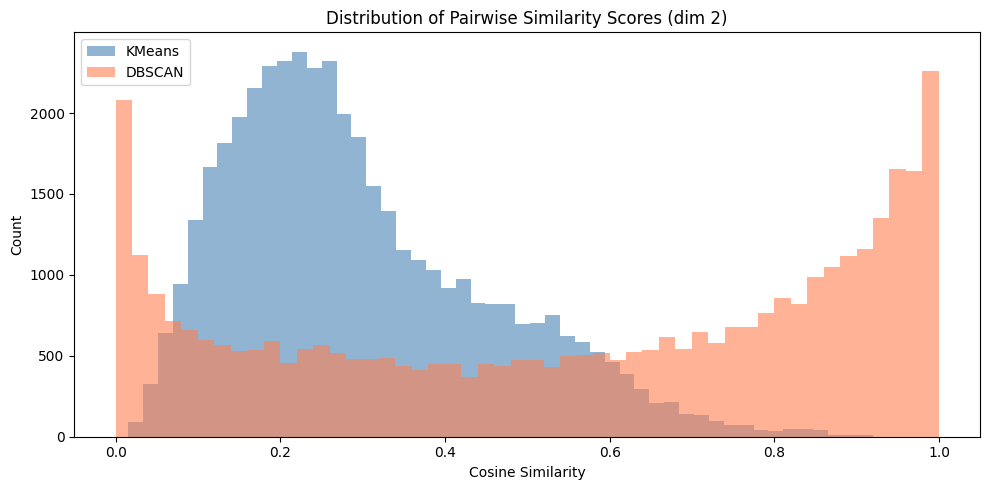

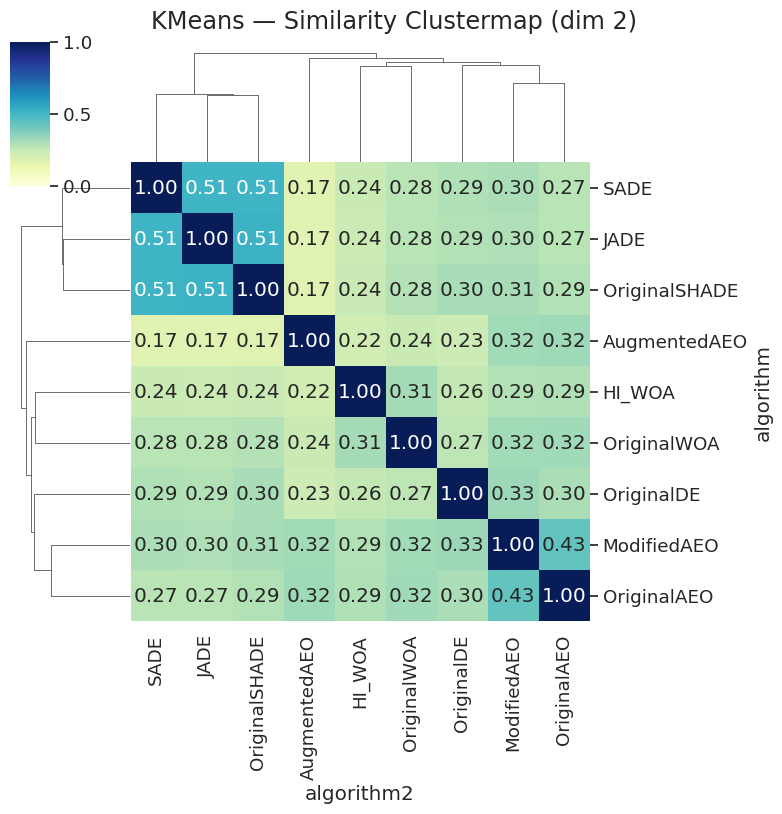

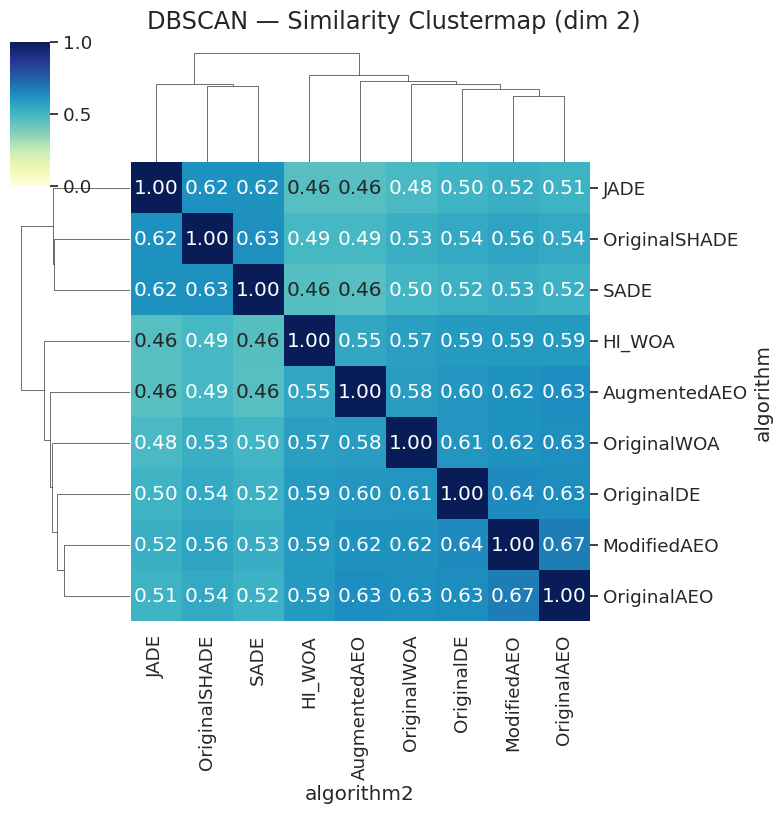

In [9]:
compare_similarity_methods([2], data_dir_dbscan=DATA_DIR_DBSCAN, data_dir_kmeans=DATA_DIR_KMEANS, save=True, eps=0.1, ms=150)